# Sentiment Analysis and Topic Modeling of US Presidential Debates from 1960 to 2024

### Daniel Henke (176182), Sven Kurth (175866), Margherita Grosso (176786), Luca Gudi (175880)

## Install and Load Packages

In [129]:
%pip install -q numpy scipy pandas matplotlib seaborn wordcloud
%pip install -q nltk spacy transformers torch wordcloud gensim
%pip install -q scikit-learn umap-learn hdbscan
%pip install -q bertopic keybert sentence-transformers
%pip install -q tensorflow==2.16.1 tf-keras
%pip install -q hf_xet ipywidgets tqdm prettytable

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


...


[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
#If any installations fail, try these versions for better compatibility
#Often incompatible packages
#%pip uninstall -y gensim scipy numpy

# Highly likely to be compatible
#%pip install scipy==1.10.1
#%pip install numpy
#pip install gensim
# Restart the Kernel

Found existing installation: gensim 4.3.2
Uninstalling gensim-4.3.2:
  Successfully uninstalled gensim-4.3.2
Found existing installation: scipy 1.15.3
Uninstalling scipy-1.15.3:
  Successfully uninstalled scipy-1.15.3
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.
ERROR: Ignored the following yanked versions: 1.11.0, 1.14.0rc1
ERROR: Ignored the following versions that require a different python version: 1.10.0 Requires-Python <3.12,>=3.8; 1.10.0rc1 Requires-Python <3.12,>=3.8; 1.10.0rc2 Requires-Python <3.12,>=3.8; 1.10.1 Requires-Python <3.12,>=3.8; 1.6.2 Requires-Python >=3.7,<3.10; 1.6.3 Requires-Python >=3.7,<3.10; 1.7.0 Requires-Python >=3.7,<3.10; 1.7.1 Requires-Python >=3.7,<3.10; 1.7.2 Requires-Python >=3.7,<3.11; 1.7.3 Requires-Python >=3.7,<3.11; 1.8.0 Requires-Python >=3.8,<3.11; 1.8.0rc1 Requires-Python >=3.8,<3.11; 1.8.0rc2 Requires-Python >=3.8,

In [130]:
import numpy
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')

import spacy
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    from spacy.cli import download
    download("en_core_web_sm")
    nlp = spacy.load("en_core_web_sm")

[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading vader_lexicon: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>


In [131]:
import os
import re
import json
import numpy as np
import pandas as pd
from collections import Counter, defaultdict
from tqdm import tqdm
tqdm.pandas()  # Adds a progress_apply method to pandas objects
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib import cm
import seaborn as sns
from wordcloud import WordCloud
from prettytable import PrettyTable
from IPython.display import display

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, TreebankWordTokenizer
from nltk.stem import WordNetLemmatizer, SnowballStemmer, PorterStemmer
from nltk.sentiment import SentimentIntensityAnalyzer

import spacy
nlp = spacy.load("en_core_web_sm")

import torch
from scipy.special import softmax

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification, AutoConfig
)

from transformers.pipelines import pipeline


from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sentence_transformers import SentenceTransformer

# Topic modeling
from bertopic import BERTopic
from keybert import KeyBERT

# Gensim
import gensim
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel, LdaSeqModel

import hf_xet

# Load and Prepare Data

## Create Dataframe for US Debates from 1960 to 2020 the Dataset from Kaggle

### Define Directory

In [133]:
DATA_DIRECTORY = "data_dir"

### Meta Data

In [135]:
INCUMBENT_PAIRS = {
    ("ford", "1976"), ("carter", "1980"), ("reagan", "1984"), ("bush", "1984"),
    ("bush", "1992"), ("quayle", "1992"), ("clinton", "1996"), ("gore", "1996"),
    ("bush", "2004"), ("cheney", "2004"), ("obama", "2012"), ("biden", "2012"),
    ("trump", "2020"), ("pence", "2020")
}

WINNER_PAIRS = {
    ("kennedy", "1960"), ("carter", "1976"), ("reagan", "1980"), ("bush", "1980"),
    ("reagan", "1984"), ("bush", "1984"), ("bush", "1988"), ("quayle", "1988"),
    ("clinton", "1992"), ("gore", "1992"), ("clinton", "1996"), ("gore", "1996"),
    ("bush", "2000"), ("cheney", "2000"), ("bush", "2004"), ("cheney", "2004"),
    ("obama", "2008"), ("biden", "2008"), ("obama", "2012"), ("biden", "2012"),
    ("trump", "2016"), ("pence", "2016"), ("biden", "2020"), ("harris", "2020")
}

CANDIDATES = {
    # Presidential
    "kennedy": "Democratic", "nixon": "Republican", "ford": "Republican",
    "carter": "Democratic", "reagan": "Republican", "anderson": "Independent",
    "mondale": "Democratic", "bush": "Republican", "dukakis": "Democratic",
    "clinton": "Democratic", "perot": "Independent", "dole": "Republican",
    "gore": "Democratic", "kerry": "Democratic", "obama": "Democratic",
    "mccain": "Republican", "romney": "Republican", "trump": "Republican",
    "biden": "Democratic",

    # Vice-Presidential
    "ferraro": "Democratic", "quayle": "Republican", "bentsen": "Democratic",
    "kemp": "Republican", "stockdale": "Independent", "lieberman": "Democratic", "cheney": "Republican",
    "edwards": "Democratic", "palin": "Republican", "ryan": "Republican",
    "kaine": "Democratic", "pence": "Republican", "harris": "Democratic",
    "vance": "Republican"
}

CANDIDATE_FIRST_NAMES = {"Kennedy": "John","Humphrey": "Hubert","McGovern": "George","Carter": "Jimmy","Mondale": "Walter",
    "Dukakis": "Michael", "Clinton Bill": "Bill", "Gore": "Al", "Kerry": "John", "Obama": "Barack", "Clinton Hillary": "Hillary",
    "Biden": "Joe","Nixon": "Richard","Goldwater": "Barry","Ford": "Gerald","Reagan": "Ronald","Bush Sr": "George",  
    "Bush Jr": "George","Dole": "Bob","Mccain": "John","Romney": "Mitt","Trump": "Donald","Kemp": "Jack","Perot": "Ross",
    "Anderson": "John","Ferraro": "Geraldine","Quayle": "Dan","Lieberman": "Joe","Edwards": "John","Palin": "Sarah",
    "Ryan": "Paul","Pence": "Mike","Harris": "Kamala","Cheney": "Dick","Bentsen": "Lloyd","Kaine": "Tim","Stockdale": "James",
    "Walz": "Tim","Vance": "J.D."
}

VP_CORRECTIONS = ["2000-10-11", "2008-09-26", "2012-10-03"]

### Functions for Data Cleaning

In [136]:
def normalize_last_name(full_name):
    """Extracts the last name and applies capitalization."""
    if not full_name or full_name == "UNKNOWN":
        return "UNKNOWN"
    return full_name.strip().split()[-1].capitalize()

def fix_duplicate_names(last_name, year, is_candidate, party):
    """Fixes duplicate names for specific cases."""
    if last_name.lower() == "bush":
        last_name = "Bush Sr" if str(year) in ["1984", "1988", "1992"] else "Bush Jr"
    elif last_name.lower() == "clinton":
        last_name = "Clinton Hillary" if str(year) == "2016" else "Clinton Bill"
    elif last_name.lower() == "edwards" and str(year) == "1960":
        is_candidate = False
        party = None
    return last_name, is_candidate, party

### Functions for Data Enrichment

In [137]:
def check_incumbent(last_name, year):
    """Returns True if candidate is incumbent that year."""
    return (last_name.lower(), str(year)) in INCUMBENT_PAIRS

def check_winner(last_name, year):
    """Returns True if candidate won in that year."""
    return (last_name.lower(), str(year)) in WINNER_PAIRS

def check_candidate(last_name):
    """Returns whether person was a candidate and their party if applicable."""
    key = last_name.lower()
    return (key in CANDIDATES), CANDIDATES.get(key)

def is_vp_debate(content):
    """Determines if a debate is a Vice-Presidential debate."""
    dialogues = [entry.get("dialogue", "").lower() for entry in content[:5]]
    return any("vice presidential" in d for d in dialogues)

def correct_vp_debate_flags(df):
    """Manually corrects VP debate flags for known false positives."""
    for d in VP_CORRECTIONS:
        df.loc[df["date"] == pd.to_datetime(d).date(), "VP_debate"] = False
    return df

def parse_date(date_list):
    """Converts a date list into a datetime.date object or returns 'UNKNOWN'."""
    try:
        return pd.to_datetime(" ".join(date_list)).date()
    except Exception:
        return pd.NaT

def add_first_name(df, actor_column="actor", new_column="first_name", name_dict=None):
    """Adds a column with first names to a DataFrame by mapping values from an actor column."""
    if name_dict is None:
        name_dict = CANDIDATE_FIRST_NAMES
    df[new_column] = df[actor_column].map(name_dict)
    return df

def generate_debate_titles(df):
    """Add a 'debate_title' column to the DataFrame."""
    debate_titles = {}
    debate_counter = defaultdict(Counter)

    for date, group in df.groupby("date"):
        year = group["year"].iloc[0]
        is_vp = group["VP_debate"].iloc[0]
        
        # Get sorted unique candidate last names
        candidate_names = sorted(set(group[group["is_candidate"]]["actor"]))
        title_base = f"{year}_" + "_".join(candidate_names)

        if is_vp:
            full_title = f"{title_base}_VP"
        else:
            # Number the debate among similar candidate sets in same year
            debate_counter[year][title_base] += 1
            count = debate_counter[year][title_base]
            full_title = f"{title_base}_{count}"

        debate_titles[date] = full_title

    df["debate_title"] = df["date"].map(debate_titles)
    return df

### Functions for Loading Data from Directory

In [138]:
def get_json_files(directory):
    """Retrieves JSON files excluding partials from a directory."""
    return [
        os.path.join(directory, f)
        for f in os.listdir(directory)
        if f.endswith(".json") and not f.startswith("part")
    ]

### Final Pipeline Functions for Data Loading and Dataframe Creation

In [139]:
def process_debate_file(file_path):
    """Processes a single JSON debate file and returns a list of parsed rows."""
    rows = []
    with open(file_path, "r", encoding="utf-8") as f:
        debate = json.load(f)
        content = debate.get("content", [])
        date = parse_date(debate.get("date", []))
        year = date.year if pd.notnull(date) else "UNKNOWN"
        vp_flag = is_vp_debate(content)

        for entry in content:
            actor_raw = entry.get("actor", "UNKNOWN")
            dialogue = entry.get("dialogue", "")
            last_name = normalize_last_name(actor_raw)

            is_candidate, party = check_candidate(last_name)
            is_incumbent = check_incumbent(last_name, year)
            is_winner = check_winner(last_name, year)

            # Fix duplicate names and candidate status
            last_name, is_candidate, party = fix_duplicate_names(last_name, year, is_candidate, party)
            first_name = CANDIDATE_FIRST_NAMES.get(last_name)

            rows.append({
                "debate_title" : None,
                "date": date,
                "year": year,
                "actor": last_name,
                "first_name": first_name,
                "dialogue": dialogue,
                "is_candidate": is_candidate,
                "party": party,
                "is_winner": is_winner,
                "VP_debate": vp_flag,
                "is_incumbent": is_incumbent
            })
    return rows
    
def debates_to_dataframe(directory):
    """Converts debate JSON files to a DataFrame."""
    
    all_rows = []
    json_files = get_json_files(directory)

    for file_path in json_files:
        all_rows.extend(process_debate_file(file_path))

    df = pd.DataFrame(all_rows)
    df = correct_vp_debate_flags(df)
    df = generate_debate_titles(df)
    return df

In [140]:
df_debates=debates_to_dataframe(DATA_DIRECTORY)
df_debates.head()

,debate_title,date,year,actor,first_name,dialogue,is_candidate,party,is_winner,VP_debate,is_incumbent
0,2020_Biden_Trump_1,2020-09-29,2020,Participants,None,Former Vice President Joe Biden (D) and,False,None,False,False,False
1,2020_Biden_Trump_1,2020-09-29,2020,Moderator,None,Chris Wallace (Fox News),False,None,False,False,False
2,2020_Biden_Trump_1,2020-09-29,2020,Wallace,None,Good evening from the Health Education Campus ...,False,None,False,False,False
3,2020_Biden_Trump_1,2020-09-29,2020,Biden,Joe,"How you doing, man?",True,Democratic,True,False,False
4,2020_Biden_Trump_1,2020-09-29,2020,Trump,Donald,How are you doing?,True,Republican,False,False,True


## Add 1992 and 2024 Debates from txt.files to Dataframe

### Function for Loading txt.files from Directory with Data Enrichment

We rely on pattern matching to separate the speakers and each statement

In [141]:
def extract_debate_txt(file_path, title, year, date, vp_debate, candidate_info):
    """Extracts structured debate data from a transcript text file.
    Args:
        file_path (str): Path to the transcript text file.
        title (str): Title of the debate.
        year (int): Year of the debate.
        date (str): Date of the debate in 'YYYY-MM-DD' format.
        vp_debate (bool): Whether this is a vice-presidential debate.
        candidate_info (dict): Dictionary mapping speaker last names to:
            {"is_candidate": bool, "party": str, "is_winner": bool, "is_incumbent": bool}
    """
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = [line.strip() for line in f if line.strip()]

    date = pd.to_datetime(date, errors="coerce").date() if date else None
    pattern = re.compile(r'^([A-Z][A-Z\s.\-]*)(?:, [A-Z\s.]+)?:\s*(.*)')

    data, current_actor, current_text = [], None, []

    def append_block(actor, text):
        if not actor or not text:
            return
    
        actor = actor.title()  # normalize
        info = candidate_info.get(actor, {
            'is_candidate': False,
            'party': None,
            'is_winner': False,
            'is_incumbent': False
        })
    
        first_name = CANDIDATE_FIRST_NAMES.get(actor)
    
        data.append({
            "debate_title": title,
            "date": date,
            "year": year,
            "actor": actor,
            "first_name": first_name,
            "dialogue": ' '.join(text).strip(),
            "is_candidate": info['is_candidate'],
            "party": info['party'],
            "is_winner": info['is_winner'],
            "VP_debate": vp_debate,
            "is_incumbent": info['is_incumbent']
        })
    

    for line in lines:
        match = pattern.match(line)
        if match:
            append_block(current_actor, current_text)
            current_actor = match.group(1).split()[-1].title()
            current_text = [match.group(2)] if match.group(2) else []
        else:
            current_text.append(line)

    append_block(current_actor, current_text)
    return pd.DataFrame(data)

### Complete and Enrich 1992 debate

In [142]:
debate_1992_first_half=extract_debate_txt(
    file_path="data_dir/transcript_1992_oct_15_first_half.txt",
    title="1992_Bush Sr_Clinton Bill_Perot_2",
    year=1992, date="1992-10-15", vp_debate=False,
    candidate_info={
        "Bush": {"is_candidate": True, "party": "Republican","is_winner": False,"is_incumbent": True},
        "Clinton": {"is_candidate": True,"party": "Democratic","is_winner": True,"is_incumbent": False},
        "Perot": {"is_candidate": True,"party": "Independent","is_winner": False,"is_incumbent": False}
    }
)

#Rename Bush to Bush Sr and Clinton to Clinton (Bill)
debate_1992_first_half.loc[debate_1992_first_half["actor"] == "Bush", "actor"] = "Bush Sr"
debate_1992_first_half.loc[debate_1992_first_half["actor"] == "Clinton", "actor"] = "Clinton Bill"

#Assign first names
debate_1992_first_half = add_first_name(debate_1992_first_half, actor_column="actor", new_column="first_name")

debate_1992_first_half.head(20)

,debate_title,date,year,actor,first_name,dialogue,is_candidate,party,is_winner,VP_debate,is_incumbent
0,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Simpson,NaN,Good evening and welcome to this second of thr...,False,None,False,False,False
1,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Bush Sr,George,Let’s go.,True,Republican,False,False,True
2,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Simpson,NaN,And I think the first question is over here.,False,None,False,False,False
3,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Question,NaN,Yes. I’d like to direct my question to Mr. Per...,False,None,False,False,False
4,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Perot,Ross,That’s right at the top of my agenda. We’ve sh...,True,Independent,False,False,False
5,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Simpson,NaN,"Thank you, Mr. Perot. I see that the president...",False,None,False,False,False
6,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Bush Sr,George,"Carole, the thing that saved us in this global...",True,Republican,False,False,True
7,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Simpson,NaN,Governor Clinton.,False,None,False,False,False
8,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Clinton Bill,Bill,"I’d like to answer the question, because I’ve ...",True,Democratic,True,False,False
9,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Simpson,NaN,Thank you. I think we have a question over here.,False,None,False,False,False


In [143]:
#concat with the rest of the data
df_debates = pd.concat([ debate_1992_first_half, df_debates], ignore_index=True)
df_debates.head(20)

,debate_title,date,year,actor,first_name,dialogue,is_candidate,party,is_winner,VP_debate,is_incumbent
0,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Simpson,NaN,Good evening and welcome to this second of thr...,False,None,False,False,False
1,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Bush Sr,George,Let’s go.,True,Republican,False,False,True
2,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Simpson,NaN,And I think the first question is over here.,False,None,False,False,False
3,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Question,NaN,Yes. I’d like to direct my question to Mr. Per...,False,None,False,False,False
4,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Perot,Ross,That’s right at the top of my agenda. We’ve sh...,True,Independent,False,False,False
5,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Simpson,NaN,"Thank you, Mr. Perot. I see that the president...",False,None,False,False,False
6,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Bush Sr,George,"Carole, the thing that saved us in this global...",True,Republican,False,False,True
7,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Simpson,NaN,Governor Clinton.,False,None,False,False,False
8,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Clinton Bill,Bill,"I’d like to answer the question, because I’ve ...",True,Democratic,True,False,False
9,1992_Bush Sr_Clinton Bill_Perot_2,1992-10-15,1992,Simpson,NaN,Thank you. I think we have a question over here.,False,None,False,False,False


### Add and Enrich 2024 Debates

In [144]:
debate_2024_biden=extract_debate_txt(
    file_path="data_dir/transcript_2024_Trump_Biden.txt",
    title="2024_Trump_Biden",
    year=2024,date="2024-07-27",vp_debate=False,
    candidate_info={
        "Trump": {"is_candidate": True,"party": "Republican","is_winner": True,"is_incumbent": False},
        "Biden": {"is_candidate": True,"party": "Democratic","is_winner": False,"is_incumbent": True}
    }
)

df_debates = pd.concat([df_debates, debate_2024_biden], ignore_index=True)
debate_2024_biden.head(20)

,debate_title,date,year,actor,first_name,dialogue,is_candidate,party,is_winner,VP_debate,is_incumbent
0,2024_Trump_Biden,2024-07-27,2024,Tapper,None,"We’re live from Georgia, a key battleground st...",False,None,False,False,False
1,2024_Trump_Biden,2024-07-27,2024,Bash,None,This debate is being produced by CNN and it’s ...,False,None,False,False,False
2,2024_Trump_Biden,2024-07-27,2024,Tapper,None,"I’m Jake Tapper, anchor of CNN’s “The Lead” an...",False,None,False,False,False
3,2024_Trump_Biden,2024-07-27,2024,Bash,None,"When it’s time for a candidate to speak, his m...",False,None,False,False,False
4,2024_Trump_Biden,2024-07-27,2024,Tapper,None,Now please welcome the 46th president of the U...,False,None,False,False,False
5,2024_Trump_Biden,2024-07-27,2024,Biden,Joe,How are you? Good to be here. Thank you.,True,Democratic,False,False,True
6,2024_Trump_Biden,2024-07-27,2024,Tapper,None,And please welcome the 45th president of the U...,False,None,False,False,False
7,2024_Trump_Biden,2024-07-27,2024,Biden,Joe,You have to take a look at what I was left whe...,True,Democratic,False,False,True
8,2024_Trump_Biden,2024-07-27,2024,Tapper,None,Thank you. President Trump?,False,None,False,False,False
9,2024_Trump_Biden,2024-07-27,2024,Trump,Donald,We had the greatest economy in the history of ...,True,Republican,True,False,False


In [145]:
debate_2024_harris=extract_debate_txt(
    file_path="data_dir/transcript_2024_Trump_Harris.txt",
    title="2024_Trump_Harris",
    year=2024,date="2024-09-10",vp_debate=False,
    candidate_info={
        "Trump": {"is_candidate": True,"party": "Republican","is_winner": True,"is_incumbent": False},
        "Harris": {"is_candidate": True,"party": "Democratic","is_winner": False,"is_incumbent": False}
    }
)

df_debates = pd.concat([df_debates, debate_2024_harris], ignore_index=True)

debate_2024_harris.head(20)

,debate_title,date,year,actor,first_name,dialogue,is_candidate,party,is_winner,VP_debate,is_incumbent
0,2024_Trump_Harris,2024-09-10,2024,Muir,None,"Tonight, the high-stakes showdown here in Phil...",False,None,False,False,False
1,2024_Trump_Harris,2024-09-10,2024,Davis,None,A historic race for president upended just wee...,False,None,False,False,False
2,2024_Trump_Harris,2024-09-10,2024,Muir,None,The candidates separated by the smallest of ma...,False,None,False,False,False
3,2024_Trump_Harris,2024-09-10,2024,Muir,None,"Good evening, I'm David Muir. And thank you fo...",False,None,False,False,False
4,2024_Trump_Harris,2024-09-10,2024,Davis,None,And I'm Linsey Davis. Tonight's meeting could ...,False,None,False,False,False
5,2024_Trump_Harris,2024-09-10,2024,Muir,None,And that brings us to the rules of tonight's d...,False,None,False,False,False
6,2024_Trump_Harris,2024-09-10,2024,Davis,None,President Trump won the coin toss. He chose to...,False,None,False,False,False
7,2024_Trump_Harris,2024-09-10,2024,Muir,None,So let's now welcome the candidates to the sta...,False,None,False,False,False
8,2024_Trump_Harris,2024-09-10,2024,Harris,Kamala,Kamala Harris. Let's have a good debate.,True,Democratic,False,False,False
9,2024_Trump_Harris,2024-09-10,2024,Trump,Donald,Nice to see you. Have fun.,True,Republican,True,False,False


In [146]:
debate_2024_vp=extract_debate_txt(
    file_path="data_dir/transcript_2024_Vance_Walz.txt",
    title="2024_Vance_Walz_VP",
    year=2024,date="2024-10-01",vp_debate=True,
    candidate_info={
        "Jdv": {"is_candidate": True,"party": "Republican","is_winner": True,"is_incumbent": False},
        "Tw": {"is_candidate": True,"party": "Democratic","is_winner": False,"is_incumbent": False}
    }
)

#Rename Jdv to Vance, Tw to Walz, No to O'Donnell, and Mb to Brennan
debate_2024_vp.loc[debate_2024_vp["actor"] == "Jdv", "actor"] = "Vance"
debate_2024_vp.loc[debate_2024_vp["actor"] == "Tw", "actor"] = "Walz"
debate_2024_vp.loc[debate_2024_vp["actor"] == "No", "actor"] = "O'Donnell"
debate_2024_vp.loc[debate_2024_vp["actor"] == "Mb", "actor"] = "Brennan"

#Assign first names
debate_2024_vp = add_first_name(debate_2024_vp, actor_column="actor", new_column="first_name")

df_debates = pd.concat([df_debates, debate_2024_vp], ignore_index=True)
debate_2024_vp.head(20)

,debate_title,date,year,actor,first_name,dialogue,is_candidate,party,is_winner,VP_debate,is_incumbent
0,2024_Vance_Walz_VP,2024-10-01,2024,O'Donnell,NaN,Good evening. I'm Norah O'Donnell and thank yo...,False,None,False,True,False
1,2024_Vance_Walz_VP,2024-10-01,2024,Brennan,NaN,I'm Margaret Brennan. In order to have a thoug...,False,None,False,True,False
2,2024_Vance_Walz_VP,2024-10-01,2024,Brennan,NaN,"Thank you, Norah. Earlier today, Iran launched...",False,None,False,True,False
3,2024_Vance_Walz_VP,2024-10-01,2024,Walz,Tim,"Well, thank you. And thank you for those joini...",True,Democratic,False,True,False
4,2024_Vance_Walz_VP,2024-10-01,2024,Brennan,NaN,"Governor, your time is up. Senator Vance, the ...",False,None,False,True,False
5,2024_Vance_Walz_VP,2024-10-01,2024,Vance,J.D.,"So, Margaret, I want to answer the question. F...",True,Republican,True,True,False
6,2024_Vance_Walz_VP,2024-10-01,2024,Brennan,NaN,"Thank you, Senator. Governor Walz, do you care...",False,None,False,True,False
7,2024_Vance_Walz_VP,2024-10-01,2024,Walz,Tim,"Well, look, Donald Trump was in office. We'll ...",True,Democratic,False,True,False
8,2024_Vance_Walz_VP,2024-10-01,2024,Brennan,NaN,"Senator Vance, the U.S. did have a diplomatic ...",False,None,False,True,False
9,2024_Vance_Walz_VP,2024-10-01,2024,Vance,J.D.,"Well, first of all, Margaret, diplomacy is not...",True,Republican,True,True,False


### Sort Rows based on Year & Add Word Count

In [147]:
df_debates.sort_values(by=["year", "date"], inplace=True)
df_debates.reset_index(drop=True, inplace=True)
df_debates['word_count'] = df_debates['dialogue'].apply(lambda x: len(str(x).split()))
df_debates

,debate_title,date,year,actor,first_name,dialogue,is_candidate,party,is_winner,VP_debate,is_incumbent,word_count
0,1960_Kennedy_Nixon_1,1960-09-26,1960,Kennedy,John,"Mr. Smith, Mr. Nixon. In the election of 1860,...",True,Democratic,True,False,False,1249
1,1960_Kennedy_Nixon_1,1960-09-26,1960,Smith,None,And now the opening statement by Vice Presiden...,False,None,False,False,False,11
2,1960_Kennedy_Nixon_1,1960-09-26,1960,Nixon,Richard,"Mr. Smith, Senator Kennedy. The things that Se...",True,Republican,False,False,False,1382
3,1960_Kennedy_Nixon_1,1960-09-26,1960,Smith,None,"Thank you, Mr. Nixon. That completes the openi...",False,None,False,False,False,62
4,1960_Kennedy_Nixon_1,1960-09-26,1960,Fleming,None,"Senator, the Vice President in his campaign ha...",False,None,False,False,False,41
...,...,...,...,...,...,...,...,...,...,...,...,...
9928,2024_Vance_Walz_VP,2024-10-01,2024,Walz,Tim,"Well, thank you, Senator Vance. Thank you to C...",True,Democratic,False,True,False,391
9929,2024_Vance_Walz_VP,2024-10-01,2024,Brennan,NaN,"Governor Walz. Thank you. Senator Vance, your ...",False,None,False,True,False,9
9930,2024_Vance_Walz_VP,2024-10-01,2024,Vance,J.D.,"Well, I want to thank Governor Walz, you folks...",True,Republican,True,True,False,452
9931,2024_Vance_Walz_VP,2024-10-01,2024,Brennan,NaN,"Senator Vance, thank you. And thank you both f...",False,None,False,True,False,23


### Save as CSV

In [148]:
# Save the final DataFrame to a CSV file
df_debates.to_csv("df_transcripts.csv", index=False, encoding="utf-8")
print(f"Data saved")

Data saved


# Exploratory Data Analysis

### Read CSV

In [149]:
df_transcripts = pd.read_csv('df_transcripts.csv')
df_candidates = df_transcripts[df_transcripts['is_candidate'] == True].copy()

In [150]:
df_transcripts.head(20)

,debate_title,date,year,actor,first_name,dialogue,is_candidate,party,is_winner,VP_debate,is_incumbent,word_count
0,1960_Kennedy_Nixon_1,1960-09-26,1960,Kennedy,John,"Mr. Smith, Mr. Nixon. In the election of 1860,...",True,Democratic,True,False,False,1249
1,1960_Kennedy_Nixon_1,1960-09-26,1960,Smith,NaN,And now the opening statement by Vice Presiden...,False,NaN,False,False,False,11
2,1960_Kennedy_Nixon_1,1960-09-26,1960,Nixon,Richard,"Mr. Smith, Senator Kennedy. The things that Se...",True,Republican,False,False,False,1382
3,1960_Kennedy_Nixon_1,1960-09-26,1960,Smith,NaN,"Thank you, Mr. Nixon. That completes the openi...",False,NaN,False,False,False,62
4,1960_Kennedy_Nixon_1,1960-09-26,1960,Fleming,NaN,"Senator, the Vice President in his campaign ha...",False,NaN,False,False,False,41
5,1960_Kennedy_Nixon_1,1960-09-26,1960,Kennedy,John,"Well, the Vice President and I came to the Con...",True,Democratic,True,False,False,186
6,1960_Kennedy_Nixon_1,1960-09-26,1960,Smith,NaN,"Mr. Nixon, would you like to comment on that s...",False,NaN,False,False,False,10
7,1960_Kennedy_Nixon_1,1960-09-26,1960,Nixon,Richard,I have no comment.,True,Republican,False,False,False,4
8,1960_Kennedy_Nixon_1,1960-09-26,1960,Smith,NaN,The next question: Mr. Novins.,False,NaN,False,False,False,5
9,1960_Kennedy_Nixon_1,1960-09-26,1960,Novins,NaN,"Mr. Vice President, your campaign stresses the...",False,NaN,False,False,False,60


In [151]:
df_transcripts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9933 entries, 0 to 9932
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   debate_title  9933 non-null   object
 1   date          9933 non-null   object
 2   year          9933 non-null   int64 
 3   actor         9933 non-null   object
 4   first_name    5653 non-null   object
 5   dialogue      9933 non-null   object
 6   is_candidate  9933 non-null   bool  
 7   party         5651 non-null   object
 8   is_winner     9933 non-null   bool  
 9   VP_debate     9933 non-null   bool  
 10  is_incumbent  9933 non-null   bool  
 11  word_count    9933 non-null   int64 
dtypes: bool(4), int64(2), object(6)
memory usage: 659.7+ KB


In [152]:
df_transcripts.describe(include="all")

,debate_title,date,year,actor,first_name,dialogue,is_candidate,party,is_winner,VP_debate,is_incumbent,word_count
count,9933,9933,9933.000000,9933,5653,9933,9933,5651,9933,9933,9933,9933.000000
unique,48,48,NaN,171,29,8563,2,3,2,2,2,NaN
top,2020_Biden_Trump_1,2020-09-29,NaN,Trump,Donald,(CROSSTALK),True,Republican,False,False,False,NaN
freq,858,858,NaN,930,930,163,5651,2990,7187,7334,8332,NaN
mean,NaN,NaN,2004.906876,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.336756
std,NaN,NaN,14.783792,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,114.001134
min,NaN,NaN,1960.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000
25%,NaN,NaN,1992.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000
50%,NaN,NaN,2008.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.000000
75%,NaN,NaN,2016.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.000000


### Explore Frequency of Statement Length (in Words) 

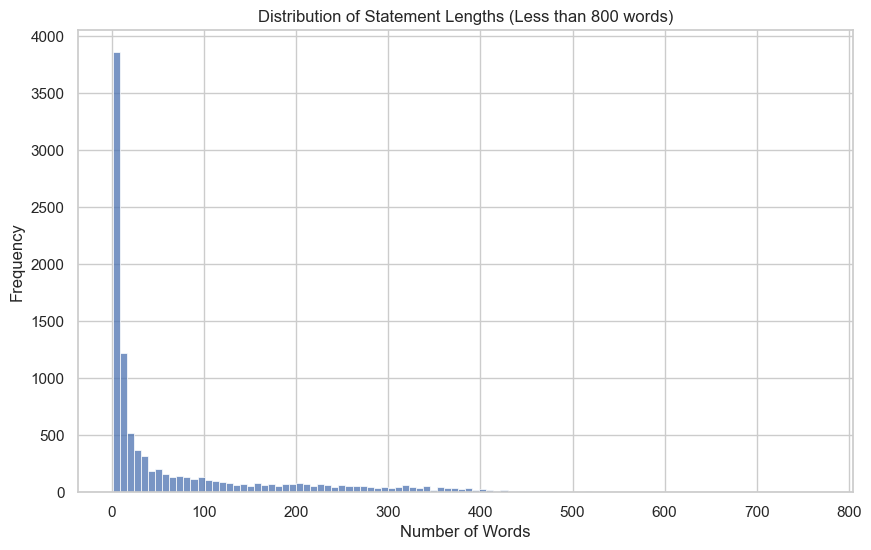

Total number of statements: 9933
Total number of candidates: 36
Total number of speeches over 800 words: 4


In [157]:
plt.figure(figsize=(10, 6))
sns.histplot(df_transcripts[df_transcripts['word_count'] < 800]['word_count'], bins=100, color='#4C72B0')
plt.title('Distribution of Statement Lengths (Less than 800 words)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

print (f"Total number of statements: {len(df_transcripts)}")
print(f"Total number of candidates: {df_candidates['actor'].nunique()}")
print(f"Total number of speeches over 800 words: {df_transcripts[df_transcripts['word_count'] > 800].shape[0]}")

We see a clear trend of many statements over very few words in a negatively exponential distribution.

### Explore Statement Length Differences across different Periods

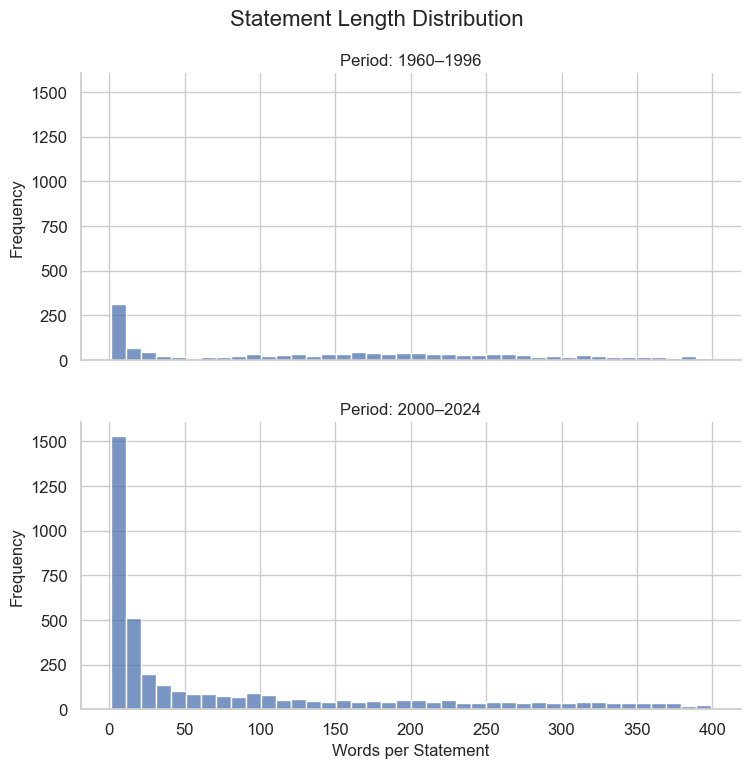

In [158]:
def map_year_block(y):
    if y < 2000:
        return "1960–1996"
    else:
        return "2000–2024"


# Limit to statements under 800 words
df_candidates_sub800 = df_candidates[df_candidates['word_count'] < 400].copy()
df_candidates_sub800['year_block'] = df_candidates_sub800['year'].apply(map_year_block)

# Plot vertically aligned with two periods
g = sns.displot(
    data=df_candidates_sub800,
    x='word_count',
    col='year_block',
    col_order=["1960–1996", "2000–2024"],
    col_wrap=1,  # vertical stacking
    height=4,
    aspect=2,
    bins=40,
    color='#4C72B0',
    facet_kws={'sharey': True}
)

g.set_titles("Period: {col_name}", size=12)
g.set_axis_labels("Words per Statement", "Frequency", fontsize=12)
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Statement Length Distribution", fontsize=16)
g.tick_params(labelsize=12)
plt.show()

In recent years, the number of short speeches has substantially increased. This is especially due to short interruptions.

In [159]:
# Compute average per span
avg_per_span = df_candidates.groupby('year')['word_count'].mean().reset_index(name='avg_statement_length')
print(avg_per_span)

    year  avg_statement_length
0   1960            353.445545
1   1976            278.336207
2   1980            248.962025
3   1984            195.238095
4   1988            159.232759
5   1992            104.437148
6   1996            174.865306
7   2000            145.920424
8   2004            182.181818
9   2008            131.915414
10  2012             77.612991
11  2016             56.208723
12  2020             41.914168
13  2024            150.811258


A similar falling trend is visible in the raw numbers, which show a clear decline in statement length per cycle. Only in 2024, the sentence length has increased again.

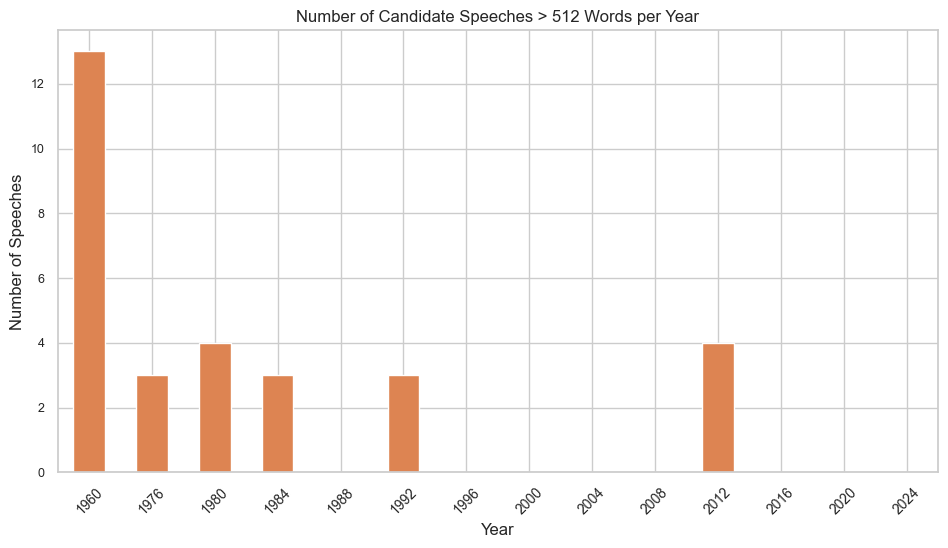

In [160]:
df_transcripts['word_count'] = df_transcripts['dialogue'].apply(lambda x: len(str(x).split()))
long_speeches = df_transcripts[df_transcripts['word_count'] > 512]
long_speeches_per_year = long_speeches.groupby('year').size()
all_years = df_transcripts['year'].unique()
long_speeches_per_year = long_speeches_per_year.reindex(sorted(all_years), fill_value=0)

plt.figure(figsize=(10, 6))
long_speeches_per_year.plot(kind='bar', color='#DD8452')
plt.title('Number of Candidate Speeches > 512 Words per Year')
plt.ylabel('Number of Speeches')
plt.xlabel('Year')
plt.xticks(rotation=45, size=10)
plt.yticks(size=9)
plt.tight_layout()
plt.show()

We notice that only in older debates speeches longer than 512 words were common, while in more recent debates they are rare. This number of 512 words is relevant because it is the maximum length of input for many transformer models, including BERT and its variants. This means that we have to employ chunking techniques to process longer speeches, which can lead to loss of context and coherence in the analysis.

### Explore Number of Words Differences between Candidates 

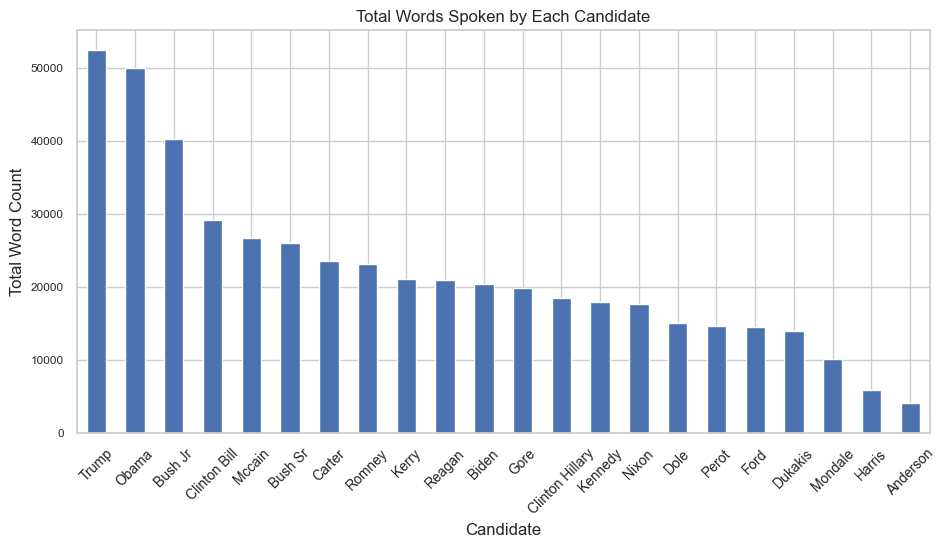

In [162]:
words_per_candidate = df_candidates[(df_candidates['VP_debate'] == False)].groupby('actor')['word_count'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
words_per_candidate.plot(kind='bar', color='#4C72B0')
plt.title('Total Words Spoken by Each Candidate')
plt.ylabel('Total Word Count')
plt.xlabel('Candidate')
plt.xticks(rotation=45, size=10)
plt.yticks(size=8.5)
plt.tight_layout()
plt.show()

We see that Donald Trump and Barack Obama have the most words spoken. However, this may be due to longer debate formats and more frequent appearances, less necessarily being more detailed within a singular debate.

### Explore Total Number of Words Differences between Candidates 

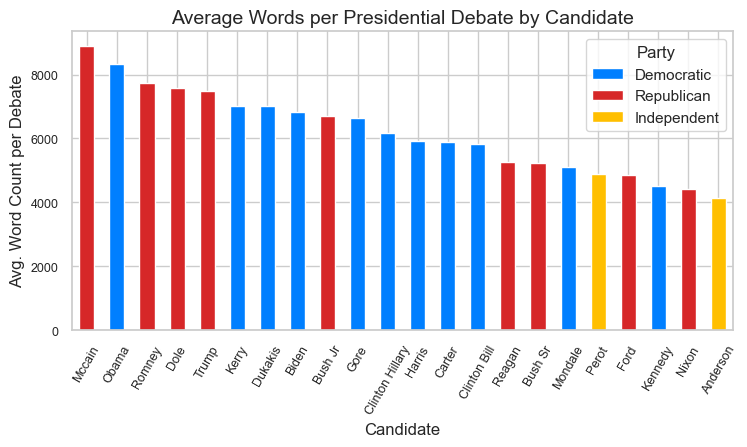

In [163]:
# Prep data
pres_debate = df_candidates[~df_candidates['VP_debate']]

avg_words = (
    pres_debate.groupby(['actor', 'date'])['word_count'].sum()
    .groupby('actor').mean()
    .sort_values(ascending=False)
)

actor_party = pres_debate.groupby('actor')['party'].agg(lambda x: x.mode().iloc[0])

party_palette = {
    'Democratic': '#007FFF',
    'Republican': '#d62728',
    'Independent': '#FFBF00'
}

colors = [party_palette.get(actor_party.get(actor, 'Independent'), '#808080') for actor in avg_words.index]

# Plot
plt.figure(figsize=(8, 5))
avg_words.plot(kind='bar', color=colors)

plt.title('Average Words per Presidential Debate by Candidate', fontsize=14)
plt.ylabel('Avg. Word Count per Debate')
plt.xlabel('Candidate')
plt.xticks(rotation=60, fontsize=9)
plt.yticks(fontsize=9)

plt.legend(
    handles=[
        Patch(facecolor=party_palette['Democratic'], label='Democratic'),
        Patch(facecolor=party_palette['Republican'], label='Republican'),
        Patch(facecolor=party_palette['Independent'], label='Independent')
    ],
    title='Party', loc='upper right'
)

plt.tight_layout()
plt.show()

We notice that actually Mccain, followed by Obama, are the most wordy speakers within a debate.

### Explore most frequent N-grams

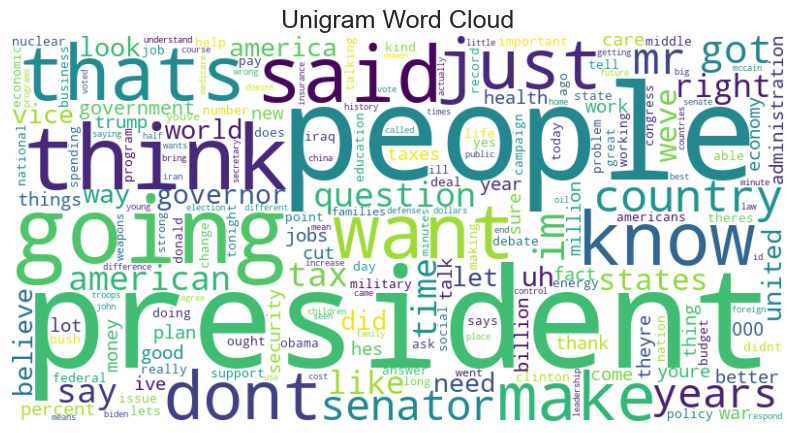

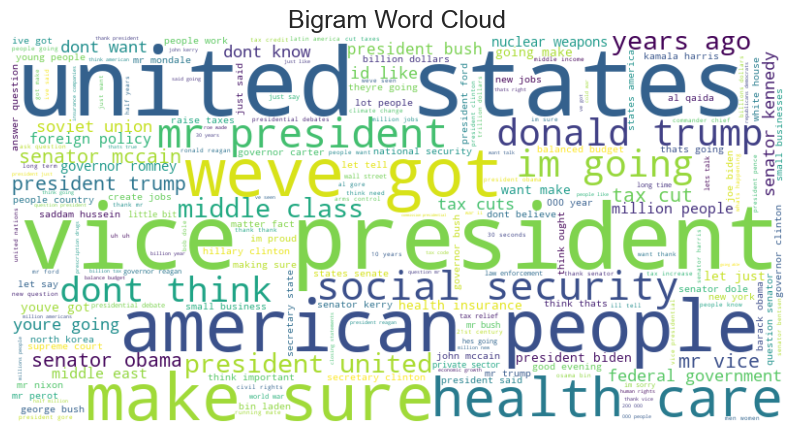

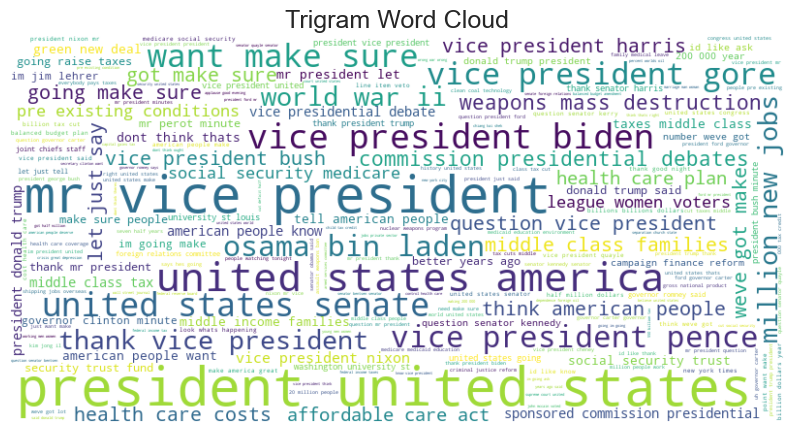

In [164]:
def generate_ngram_wordcloud(text, ngram_range=(1,1), title="Unigram Word Cloud"):
    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words='english')
    X = vectorizer.fit_transform([text])
    freqs = X.toarray().sum(axis=0)
    vocab = vectorizer.get_feature_names_out()
    freq_dict = dict(zip(vocab, freqs))

    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(freq_dict)

    plt.figure(figsize=(10, 6))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title, fontsize=18)
    plt.axis("off")
    plt.show()

text = " ".join(df_transcripts["dialogue"].dropna())

generate_ngram_wordcloud(text, ngram_range=(1,1), title="Unigram Word Cloud")
generate_ngram_wordcloud(text, ngram_range=(2,2), title="Bigram Word Cloud")
generate_ngram_wordcloud(text, ngram_range=(3,3), title="Trigram Word Cloud")

# Sentiment Analysis

### Apply VADER

In [165]:
vader = SentimentIntensityAnalyzer()

In [166]:
%%time
def analyze_vader(text):
    scores = vader.polarity_scores(text)
    return scores

def add_vader_sentiment(df, text_column='dialogue'):
    print("Applying VADER:")
    df['vader_full']= df[text_column].progress_apply(analyze_vader)
    df['vader_sentiment'] = df['vader_full'].apply(lambda x: x['compound'])
    df['vader_label']= df['vader_sentiment'].apply(lambda x: 'positive' if x > 0.05 else ('negative' if x < -0.05 else 'neutral'))
    return df

#Test Output
add_vader_sentiment(df_transcripts.head(20), 'dialogue')

Applying VADER:


100%|██████████| 20/20 [00:00<00:00, 501.59it/s]

CPU times: user 32.6 ms, sys: 11.4 ms, total: 44.1 ms
Wall time: 54.7 ms


,debate_title,date,year,actor,first_name,dialogue,is_candidate,party,is_winner,VP_debate,is_incumbent,word_count,vader_full,vader_sentiment,vader_label
0,1960_Kennedy_Nixon_1,1960-09-26,1960,Kennedy,John,"Mr. Smith, Mr. Nixon. In the election of 1860,...",True,Democratic,True,False,False,1249,"{'neg': 0.074, 'neu': 0.758, 'pos': 0.169, 'co...",0.9993,positive
1,1960_Kennedy_Nixon_1,1960-09-26,1960,Smith,NaN,And now the opening statement by Vice Presiden...,False,NaN,False,False,False,11,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,neutral
2,1960_Kennedy_Nixon_1,1960-09-26,1960,Nixon,Richard,"Mr. Smith, Senator Kennedy. The things that Se...",True,Republican,False,False,False,1382,"{'neg': 0.037, 'neu': 0.834, 'pos': 0.129, 'co...",0.9992,positive
3,1960_Kennedy_Nixon_1,1960-09-26,1960,Smith,NaN,"Thank you, Mr. Nixon. That completes the openi...",False,NaN,False,False,False,62,"{'neg': 0.0, 'neu': 0.961, 'pos': 0.039, 'comp...",0.3612,positive
4,1960_Kennedy_Nixon_1,1960-09-26,1960,Fleming,NaN,"Senator, the Vice President in his campaign ha...",False,NaN,False,False,False,41,"{'neg': 0.05, 'neu': 0.95, 'pos': 0.0, 'compou...",-0.2732,negative
5,1960_Kennedy_Nixon_1,1960-09-26,1960,Kennedy,John,"Well, the Vice President and I came to the Con...",True,Democratic,True,False,False,186,"{'neg': 0.0, 'neu': 0.82, 'pos': 0.18, 'compou...",0.9856,positive
6,1960_Kennedy_Nixon_1,1960-09-26,1960,Smith,NaN,"Mr. Nixon, would you like to comment on that s...",False,NaN,False,False,False,10,"{'neg': 0.0, 'neu': 0.783, 'pos': 0.217, 'comp...",0.3612,positive
7,1960_Kennedy_Nixon_1,1960-09-26,1960,Nixon,Richard,I have no comment.,True,Republican,False,False,False,4,"{'neg': 0.524, 'neu': 0.476, 'pos': 0.0, 'comp...",-0.2960,negative
8,1960_Kennedy_Nixon_1,1960-09-26,1960,Smith,NaN,The next question: Mr. Novins.,False,NaN,False,False,False,5,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,neutral
9,1960_Kennedy_Nixon_1,1960-09-26,1960,Novins,NaN,"Mr. Vice President, your campaign stresses the...",False,NaN,False,False,False,60,"{'neg': 0.047, 'neu': 0.879, 'pos': 0.074, 'co...",0.1779,positive


### Apply RoBERTa

In [167]:
# Load model and tokenizer
model_path = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model.eval()

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
         

In [168]:
# Shared helper: compute sentiment from logits
def compute_sentiment_from_logits(logits):
    probs = softmax(logits.detach().cpu().numpy())
    score_dict = {k: float(v) for k, v in zip(["neg", "neu", "pos"], np.round(probs, 4))}
    polarity_raw = float(np.sum(np.array([-1, 0, 1]) * probs))
    polarity_vader_scaled = float(np.tanh(2 * polarity_raw))
    return pd.Series([score_dict, polarity_raw, polarity_vader_scaled])

In [169]:
# Chunk text into overlapping slices of input_ids
def chunk_text(text, max_length=512, stride=20):
    tokens = tokenizer(text, return_tensors="pt", truncation=False)["input_ids"][0]
    return [tokens[i:i + max_length] for i in range(0, len(tokens), max_length - stride)]

In [170]:
# Sentiment for long texts using chunking
def analyze_long_text(text):
    try:
        token_chunks = chunk_text(text)
        probs_all = []

        for chunk in token_chunks:
            input_ids = chunk.unsqueeze(0)
            attention_mask = torch.ones_like(input_ids)

            with torch.no_grad():
                output = model(input_ids=input_ids, attention_mask=attention_mask)
                probs = softmax(output.logits[0].detach().cpu().numpy())
                probs_all.append(probs)

        avg_probs = np.mean(probs_all, axis=0)
        return compute_sentiment_from_logits(torch.tensor(avg_probs))

    except Exception as e:
        print("Error during long text inference:", e)
        return pd.Series([{"neg": 0.0, "neu": 1.0, "pos": 0.0}, 0.0, 0.0])

In [171]:
# Main function: choose normal or chunked analysis
def analyze_full_sentiment(text, max_length=512):
    try:
        if len(tokenizer.encode(text, truncation=False)) <= max_length:
            encoded = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_length)
            with torch.no_grad():
                output = model(**encoded)
            return compute_sentiment_from_logits(output.logits[0])
        else:
            return analyze_long_text(text)
    except Exception as e:
        print("Error in adaptive sentiment analysis:", e)
        return pd.Series([{"neg": 0.0, "neu": 1.0, "pos": 0.0}, 0.0, 0.0])

# DataFrame application
def add_bert_sentiment(df, text_column="dialogue"):
    print("Applying RoBERTa:")
    df[['bert_full', 'bert_raw', 'bert_sentiment']] = df[text_column].progress_apply(analyze_full_sentiment)
    df['bert_label'] = df['bert_sentiment'].apply(lambda x: 'positive' if x > 0.05 else ('negative' if x < -0.05 else 'neutral'))
    return df

In [172]:
def add_diff_sentiment(df, text_column='dialogue'):
    df = add_vader_sentiment(df, text_column)
    df = add_bert_sentiment(df, text_column)
    df['diff_sentiment'] = df['vader_sentiment'] - df['bert_sentiment']
    return df

In [173]:
%%time
df_candidates = add_diff_sentiment(df_candidates, text_column='dialogue')
df_candidates.to_csv('candidate_transcripts_sentiment.csv', index=False)

Applying VADER:


100%|██████████| 5651/5651 [00:02<00:00, 2259.79it/s]


Applying RoBERTa:


100%|██████████| 5651/5651 [06:39<00:00, 14.15it/s]

CPU times: user 8min 36s, sys: 1min 13s, total: 9min 50s
Wall time: 6min 41s


### See Results

In [174]:
df_candidates=pd.read_csv('candidate_transcripts_sentiment.csv')
df_candidates_pres = df_candidates[(~df_candidates["VP_debate"])]
df_candidates_vice = df_candidates[(df_candidates["VP_debate"])]

#### Checking the Impact of Vice Presidential Debates

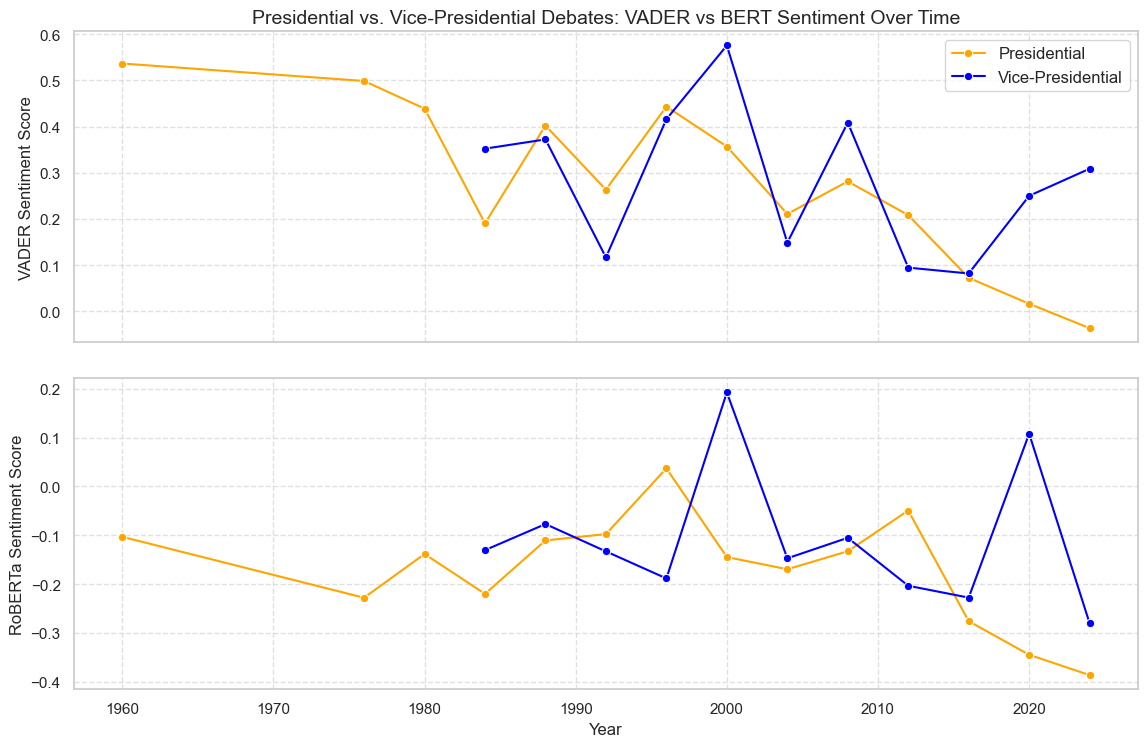

In [176]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

df_pres_debate = df_candidates_pres[(df_candidates_pres["VP_debate"] == False) & (df_candidates_pres["is_candidate"])]
avg_sentiment_pres = df_pres_debate.groupby(['date', 'year'])[['bert_sentiment', 'vader_sentiment']].mean().reset_index()

df_vice_debate = df_candidates_vice[(df_candidates_vice["VP_debate"] == True) & (df_candidates_vice["is_candidate"])]
avg_sentiment_vice = df_vice_debate.groupby(['date', 'year'])[['bert_sentiment', 'vader_sentiment']].mean().reset_index()

# Plot 1: All Debates
sns.lineplot(data=avg_sentiment_pres, x='year', y='vader_sentiment', ax=axes[0], label='Presidential', color='orange', marker='o', errorbar=None)
sns.lineplot(data=avg_sentiment_vice, x='year', y='vader_sentiment', ax=axes[0], label='Vice-Presidential', color='blue', marker='o', errorbar=None)
axes[0].set_title('Presidential vs. Vice-Presidential Debates: VADER vs BERT Sentiment Over Time', fontsize=14)
axes[0].set_ylabel('VADER Sentiment Score', fontsize=12)
axes[0].legend(fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot 2: Presidential Debates
sns.lineplot(data=avg_sentiment_pres, x='year', y='bert_sentiment', ax=axes[1], color='orange', marker='o', errorbar=None)
sns.lineplot(data=avg_sentiment_vice, x='year', y='bert_sentiment', ax=axes[1], color='blue', marker='o', errorbar=None)
axes[1].set_title('')
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('RoBERTa Sentiment Score', fontsize=12)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

We can clearly see that vice presidential debates are often massive outlier compared to their presidential counterparts. Due to this, we want to focus on only presidential debates for the sentiment analysis, as the sentiments of the actual presidential debate is most central to our research

#### Polarity Distribution across Presidential Debates

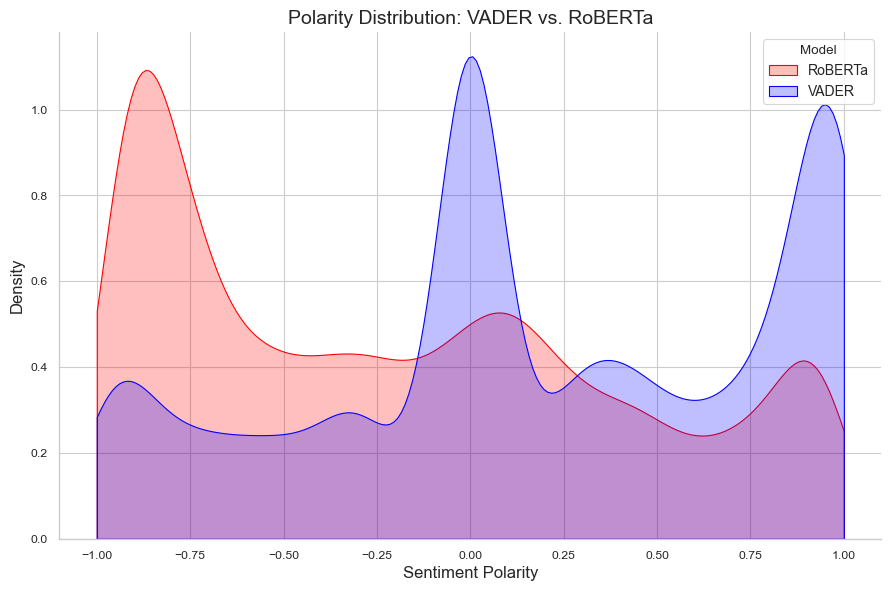

In [181]:
plt.figure(figsize=(9, 6))
sns.set(style="whitegrid", palette="colorblind", context="paper")

# KDE plot for RoBERTa and VADER
sns.kdeplot(df_candidates_pres["bert_sentiment"], color="red", fill=True, label="RoBERTa", bw_adjust=0.75, clip=(-1, 1))
sns.kdeplot(df_candidates_pres["vader_sentiment"], color="blue", fill=True, label="VADER",  bw_adjust=0.75, clip=(-1, 1))
#plt.xlim(-1, 1)
plt.xlabel("Sentiment Polarity", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title("Polarity Distribution: VADER vs. RoBERTa", fontsize=14)
plt.legend(title="Model", fontsize=10)
sns.despine()
plt.tight_layout()
plt.show()

#### Label Distribution across Presidential Debates

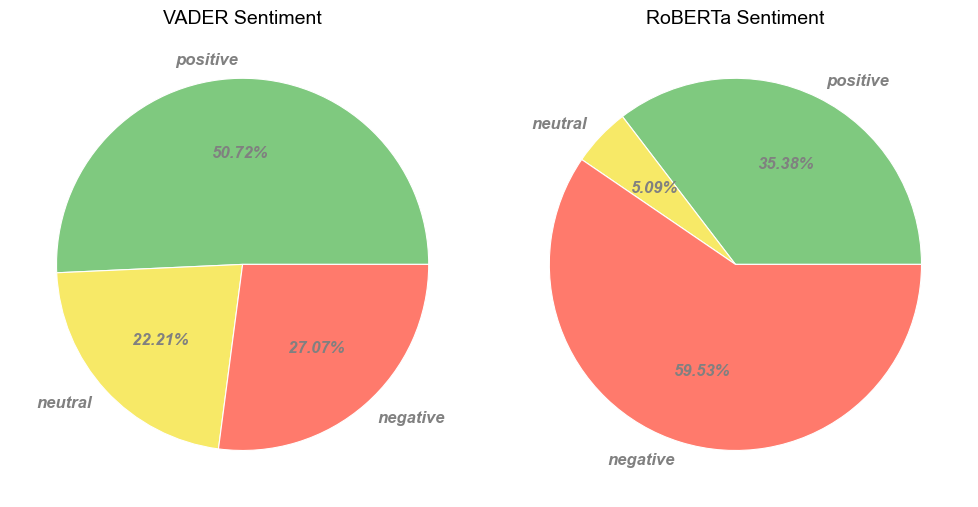

In [182]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

color_map = {
    "positive": "#7FC97F",  # green
    "neutral":  "#F7E967",   # yellow
    "negative": "#ff7a6c"   # red
}

textprops = dict(fontsize=12, fontstyle="italic", weight="bold", color="grey")

# VADER pie chart
vader_counts = df_candidates_pres["vader_label"].value_counts(normalize=True)
vader_labels = ["positive", "neutral", "negative"]
vader_colors = [color_map[label] for label in vader_labels if label in vader_counts.index]
vader_counts = vader_counts.reindex(vader_labels).dropna()

axes[0].pie(
    vader_counts,
    labels=vader_counts.index,
    autopct="%.2f%%",
    colors=vader_colors,
    textprops=textprops
)
axes[0].set_title("VADER Sentiment", fontsize=14, color="black")

# RoBERTa pie chart
bert_counts = df_candidates_pres["bert_label"].value_counts(normalize=True)
bert_labels = ["positive", "neutral", "negative"]
bert_colors = [color_map[label] for label in bert_labels if label in bert_counts.index]
bert_counts = bert_counts.reindex(bert_labels).dropna()

axes[1].pie(
    bert_counts,
    labels=bert_counts.index,
    autopct="%.2f%%",
    colors=bert_colors,
    textprops=textprops
)
axes[1].set_title("RoBERTa Sentiment", fontsize=14, color="black")

plt.tight_layout()
plt.show()

In [183]:
def sentiment_summary_stats(df, cols=['bert_sentiment', 'vader_sentiment'], group_by_column=None, display_categories=None):
    def compute_stats(sub_df):
        stats = {}
        for col in cols:
            values = sub_df[col].dropna()
            stats[col] = {
                'count': values.count(),
                'mean': values.mean(),
                'median': values.median(),
                'std': values.std(),
                'min': values.min(),
                'max': values.max(),
                '25%': values.quantile(0.25),
                '75%': values.quantile(0.75),
                'skew': values.skew(),
            }
        return pd.DataFrame(stats).T

    if group_by_column:
        results = {}
        for group, sub_df in df.groupby(group_by_column):
            results[group] = compute_stats(sub_df)
            if display_categories and group in display_categories:
                display(results[group].style.format("{:.3f}").set_caption(f"{group} Sentiment Stats"))         
        return results
    else:
        summary = compute_stats(df)
        display(summary.style.format("{:.3f}").set_caption("Sentiment Summary Statistics"))
        return summary

summary = sentiment_summary_stats(df_candidates_pres)

,count,mean,median,std,min,max,25%,75%,skew
bert_sentiment,4030.000,-0.197,-0.283,0.606,-0.957,0.961,-0.778,0.254,0.425
vader_sentiment,4030.000,0.189,0.077,0.611,-0.999,1.000,-0.190,0.810,-0.285


In [184]:
party_summary = sentiment_summary_stats(df_candidates_pres, group_by_column='party', display_categories=['Democratic', 'Republican', 'Independent'])

,count,mean,median,std,min,max,25%,75%,skew
bert_sentiment,1748.000,-0.169,-0.249,0.606,-0.957,0.961,-0.748,0.282,0.388
vader_sentiment,1748.000,0.193,0.093,0.627,-0.997,1.000,-0.243,0.836,-0.308


,count,mean,median,std,min,max,25%,75%,skew
bert_sentiment,121.000,-0.182,-0.238,0.535,-0.936,0.950,-0.634,0.194,0.346
vader_sentiment,121.000,0.164,0.077,0.593,-0.986,0.995,-0.138,0.685,-0.266


,count,mean,median,std,min,max,25%,75%,skew
bert_sentiment,2161.000,-0.221,-0.312,0.610,-0.957,0.961,-0.811,0.235,0.462
vader_sentiment,2161.000,0.187,0.077,0.599,-0.999,1.000,-0.153,0.791,-0.265


In [185]:
incumbent_summary = sentiment_summary_stats(df_candidates_pres, group_by_column='is_incumbent', display_categories=[True, False])

,count,mean,median,std,min,max,25%,75%,skew
bert_sentiment,2876.000,-0.207,-0.298,0.603,-0.957,0.961,-0.777,0.235,0.456
vader_sentiment,2876.000,0.190,0.130,0.619,-0.999,1.000,-0.250,0.821,-0.296


,count,mean,median,std,min,max,25%,75%,skew
bert_sentiment,1154.000,-0.173,-0.236,0.615,-0.954,0.961,-0.784,0.292,0.350
vader_sentiment,1154.000,0.186,0.000,0.591,-0.998,0.998,0.000,0.777,-0.253


In [186]:
winner_summary = sentiment_summary_stats(df_candidates_pres, group_by_column='is_winner', display_categories=[True, False])

,count,mean,median,std,min,max,25%,75%,skew
bert_sentiment,2063.000,-0.179,-0.239,0.607,-0.954,0.961,-0.772,0.262,0.379
vader_sentiment,2063.000,0.204,0.128,0.604,-0.997,1.000,-0.103,0.817,-0.316


,count,mean,median,std,min,max,25%,75%,skew
bert_sentiment,1967.000,-0.217,-0.325,0.606,-0.957,0.961,-0.783,0.237,0.475
vader_sentiment,1967.000,0.173,0.012,0.619,-0.999,1.000,-0.296,0.805,-0.251


In [187]:
actor_summary = sentiment_summary_stats(df_candidates_pres, group_by_column='actor', display_categories=['Trump', 'Biden', 'Harris', 'Clinton Hillary'])

,count,mean,median,std,min,max,25%,75%,skew
bert_sentiment,398.000,-0.295,-0.396,0.583,-0.957,0.961,-0.852,0.140,0.577
vader_sentiment,398.000,0.023,0.000,0.500,-0.992,0.991,-0.310,0.356,-0.070


,count,mean,median,std,min,max,25%,75%,skew
bert_sentiment,226.000,-0.134,-0.171,0.657,-0.952,0.958,-0.841,0.412,0.222
vader_sentiment,226.000,0.139,0.034,0.575,-0.993,0.996,-0.289,0.632,-0.247


,count,mean,median,std,min,max,25%,75%,skew
bert_sentiment,35.000,-0.352,-0.467,0.579,-0.937,0.926,-0.862,0.104,0.795
vader_sentiment,35.000,0.302,0.617,0.707,-0.986,0.996,-0.163,0.943,-0.610


,count,mean,median,std,min,max,25%,75%,skew
bert_sentiment,930.000,-0.360,-0.603,0.599,-0.957,0.961,-0.893,0.089,0.773
vader_sentiment,930.000,-0.015,0.000,0.516,-0.999,0.998,-0.361,0.318,-0.004


In [188]:
year_summary = sentiment_summary_stats(df_candidates_pres, group_by_column='year', display_categories=[2024, 2020, 2016, 2012, 2008, 2004, 2000, 1996, 1992, 1988, 1984, 1980, 1976, 1960])

,count,mean,median,std,min,max,25%,75%,skew
bert_sentiment,101.000,-0.106,-0.167,0.465,-0.909,0.955,-0.408,0.096,0.533
vader_sentiment,101.000,0.542,0.917,0.632,-0.983,1.000,0.273,0.983,-1.274


,count,mean,median,std,min,max,25%,75%,skew
bert_sentiment,116.000,-0.227,-0.276,0.533,-0.937,0.954,-0.750,0.155,0.343
vader_sentiment,116.000,0.500,0.842,0.666,-0.993,0.998,0.252,0.984,-1.244


,count,mean,median,std,min,max,25%,75%,skew
bert_sentiment,79.000,-0.142,-0.150,0.556,-0.918,0.952,-0.599,0.219,0.414
vader_sentiment,79.000,0.401,0.840,0.726,-0.997,0.997,-0.210,0.963,-0.938


,count,mean,median,std,min,max,25%,75%,skew
bert_sentiment,115.000,-0.216,-0.323,0.531,-0.933,0.931,-0.713,0.229,0.421
vader_sentiment,115.000,0.196,0.402,0.712,-0.997,0.996,-0.425,0.869,-0.457


,count,mean,median,std,min,max,25%,75%,skew
bert_sentiment,166.000,-0.110,-0.102,0.586,-0.941,0.959,-0.649,0.309,0.268
vader_sentiment,166.000,0.403,0.554,0.596,-0.997,0.998,0.000,0.956,-0.782


...

,count,mean,median,std,min,max,25%,75%,skew
bert_sentiment,445.000,-0.192,-0.297,0.588,-0.950,0.955,-0.748,0.237,0.475
vader_sentiment,445.000,0.227,0.272,0.617,-0.992,0.998,-0.077,0.844,-0.383


,count,mean,median,std,min,max,25%,75%,skew
bert_sentiment,438.000,-0.047,-0.023,0.615,-0.949,0.961,-0.638,0.441,0.091
vader_sentiment,438.000,0.207,0.000,0.556,-0.994,0.999,0.000,0.730,-0.242


,count,mean,median,std,min,max,25%,75%,skew
bert_sentiment,568.000,-0.280,-0.483,0.642,-0.956,0.959,-0.881,0.208,0.583
vader_sentiment,568.000,0.065,0.000,0.569,-0.997,0.996,-0.345,0.493,-0.086


,count,mean,median,std,min,max,25%,75%,skew
bert_sentiment,816.000,-0.314,-0.444,0.583,-0.957,0.961,-0.874,0.121,0.617
vader_sentiment,816.000,0.008,0.000,0.443,-0.989,0.998,-0.279,0.273,0.004


,count,mean,median,std,min,max,25%,75%,skew
bert_sentiment,205.000,-0.390,-0.686,0.600,-0.957,0.961,-0.898,0.077,0.870
vader_sentiment,205.000,-0.033,0.000,0.699,-0.999,0.996,-0.769,0.593,0.011


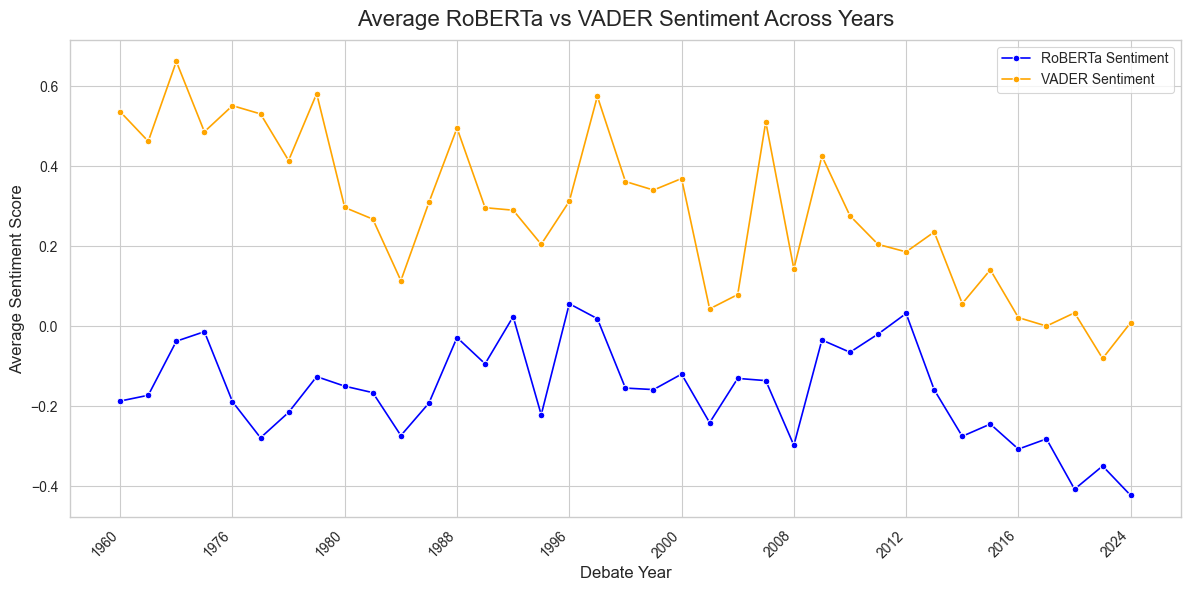

In [191]:
# Extract year first, then group
df_candidates_pres['year'] = pd.to_datetime(df_candidates_pres['date']).dt.year

# Calculate average sentiment per debate and keep the year
avg_sentiment = df_candidates_pres.groupby(['debate_title', 'year'])[['bert_sentiment', 'vader_sentiment']].mean().reset_index()

# Plot with debate titles but label x-axis with year
plt.figure(figsize=(12, 6))

sns.lineplot(data=avg_sentiment, x='debate_title', y='bert_sentiment', label='RoBERTa Sentiment', color='blue', marker='o')
sns.lineplot(data=avg_sentiment, x='debate_title', y='vader_sentiment', label='VADER Sentiment', color='orange', marker='o')

# Replace x-axis labels with years
# Base tick positions: every 4th
tick_positions = list(range(0, len(avg_sentiment), 4))
if (len(avg_sentiment) - 1) not in tick_positions:
    tick_positions.append(len(avg_sentiment) - 1)

# Corresponding year labels
tick_labels = list(avg_sentiment['year'].iloc[tick_positions])

# Apply ticks and labels
plt.xticks(ticks=tick_positions, labels=tick_labels, rotation=45, fontsize=10, ha='right')


plt.title('Average RoBERTa vs VADER Sentiment Across Years', fontsize=16, pad=10)
plt.xlabel('Debate Year', fontsize=12)
plt.ylabel('Average Sentiment Score', fontsize=12)
plt.yticks(fontsize=10)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

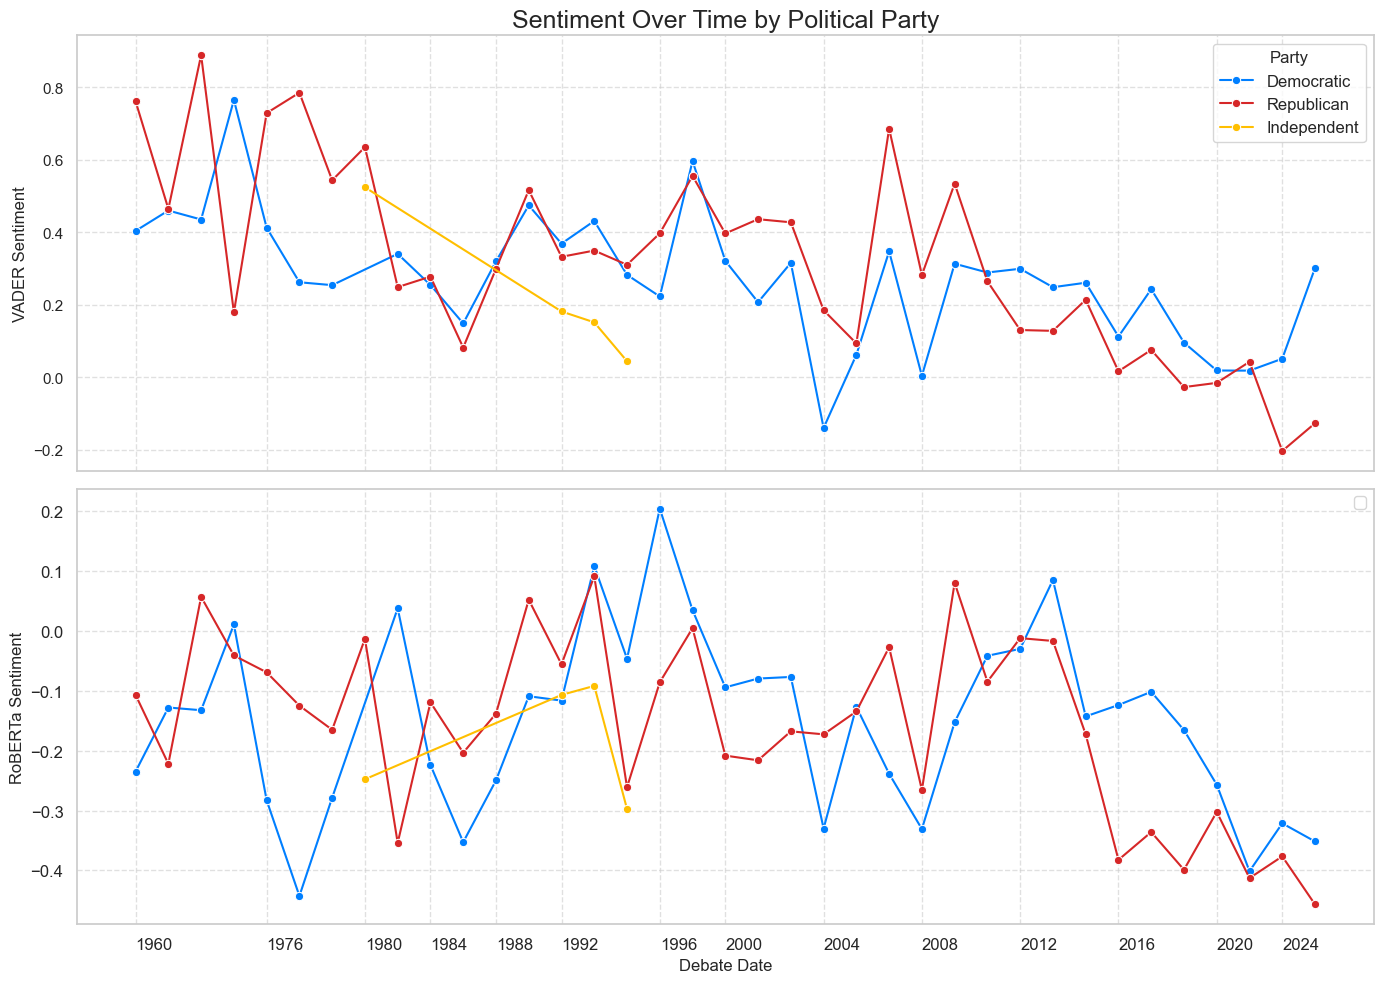

In [217]:
# Group data
avg_sentiment_party = df_candidates_pres.groupby(['date', 'year', 'party'])[['bert_sentiment', 'vader_sentiment']].mean().reset_index()

sns.set(style='whitegrid')

party_palette = {
    'Democratic': '#007FFF',
    'Republican': '#d62728',
    'Independent': '#FFBF00'
}

# Find the first available date per decade
unique_dates = avg_sentiment_party[['date', 'year']].drop_duplicates('year').sort_values('year')
tick_positions = unique_dates['date'].tolist()
tick_labels = unique_dates['year'].tolist()

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 10), sharex=True)

# VADER Plot
sns.lineplot(
    data=avg_sentiment_party,
    x='date',
    y='vader_sentiment',
    hue='party',
    marker='o',
    errorbar=None,
    palette=party_palette,
    ax=axes[0]
)
axes[0].set_title('Sentiment Over Time by Political Party', fontsize=18)
axes[0].set_ylabel('VADER Sentiment', fontsize=12)
axes[0].legend(title='Party', fontsize=12, title_fontsize=12)
axes[0].grid(True, linestyle='--', alpha=0.6)

# BERT Plot
sns.lineplot(
    data=avg_sentiment_party,
    x='date',
    y='bert_sentiment',
    hue='party',
    marker='o',
    errorbar=None,
    palette=party_palette,
    ax=axes[1]
)
axes[1].set_xlabel('Debate Date', fontsize=12)
axes[1].set_ylabel('RoBERTa Sentiment', fontsize=12)
axes[1].legend('')
axes[1].grid(True, linestyle='--', alpha=0.6)

# Apply custom ticks at 10-year intervals
plt.xticks(ticks=tick_positions, labels=tick_labels, ha='left', fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

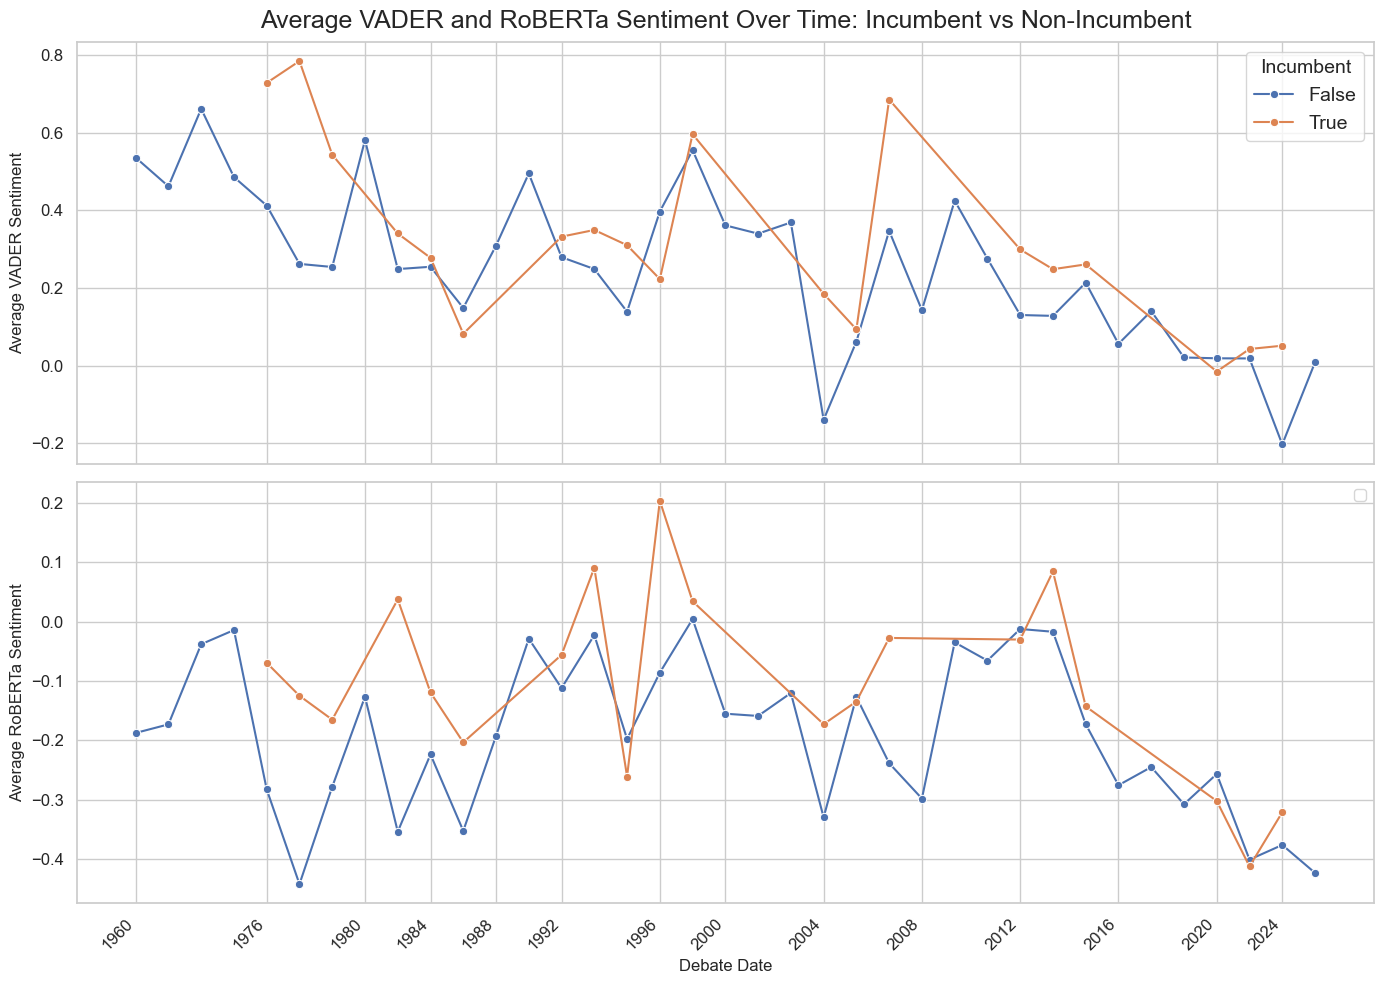

In [215]:
# Set global font size
sns.set(style='whitegrid')

# Create subplot
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# VADER plot
sns.lineplot(
    data=df_candidates_pres,
    x='date',
    y='vader_sentiment',
    hue='is_incumbent',
    errorbar=None,
    marker='o',
    ax=axes[0]
)
axes[0].set_title('Average VADER and RoBERTa Sentiment Over Time: Incumbent vs Non-Incumbent', fontsize=18, pad=10)
axes[0].set_ylabel('Average VADER Sentiment', fontsize=12)
axes[0].legend(title='Incumbent', fontsize=14, title_fontsize=14)
axes[0].tick_params(axis='both', labelsize=12)
axes[0].grid(True)

# RoBERTa plot
sns.lineplot(
    data=df_candidates_pres,
    x='date',
    y='bert_sentiment',
    hue='is_incumbent',
    errorbar=None,
    marker='o',
    ax=axes[1]
)
axes[1].set_title('')
axes[1].set_xlabel('Debate Date', fontsize=12)
axes[1].set_ylabel('Average RoBERTa Sentiment', fontsize=12)
axes[1].legend('')
axes[1].tick_params(axis='both', labelsize=12)
axes[1].grid(True)

# Set x-axis ticks at the first available date in each decade
unique_dates = df_candidates_pres[['date', 'year']].drop_duplicates().sort_values('date')
ticks = unique_dates.groupby('year').first().reset_index()
tick_positions = ticks['date'].tolist()
tick_labels = ticks['year'].tolist()

axes[1].set_xticks(tick_positions)
axes[1].set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=12)

plt.tight_layout()
plt.show()

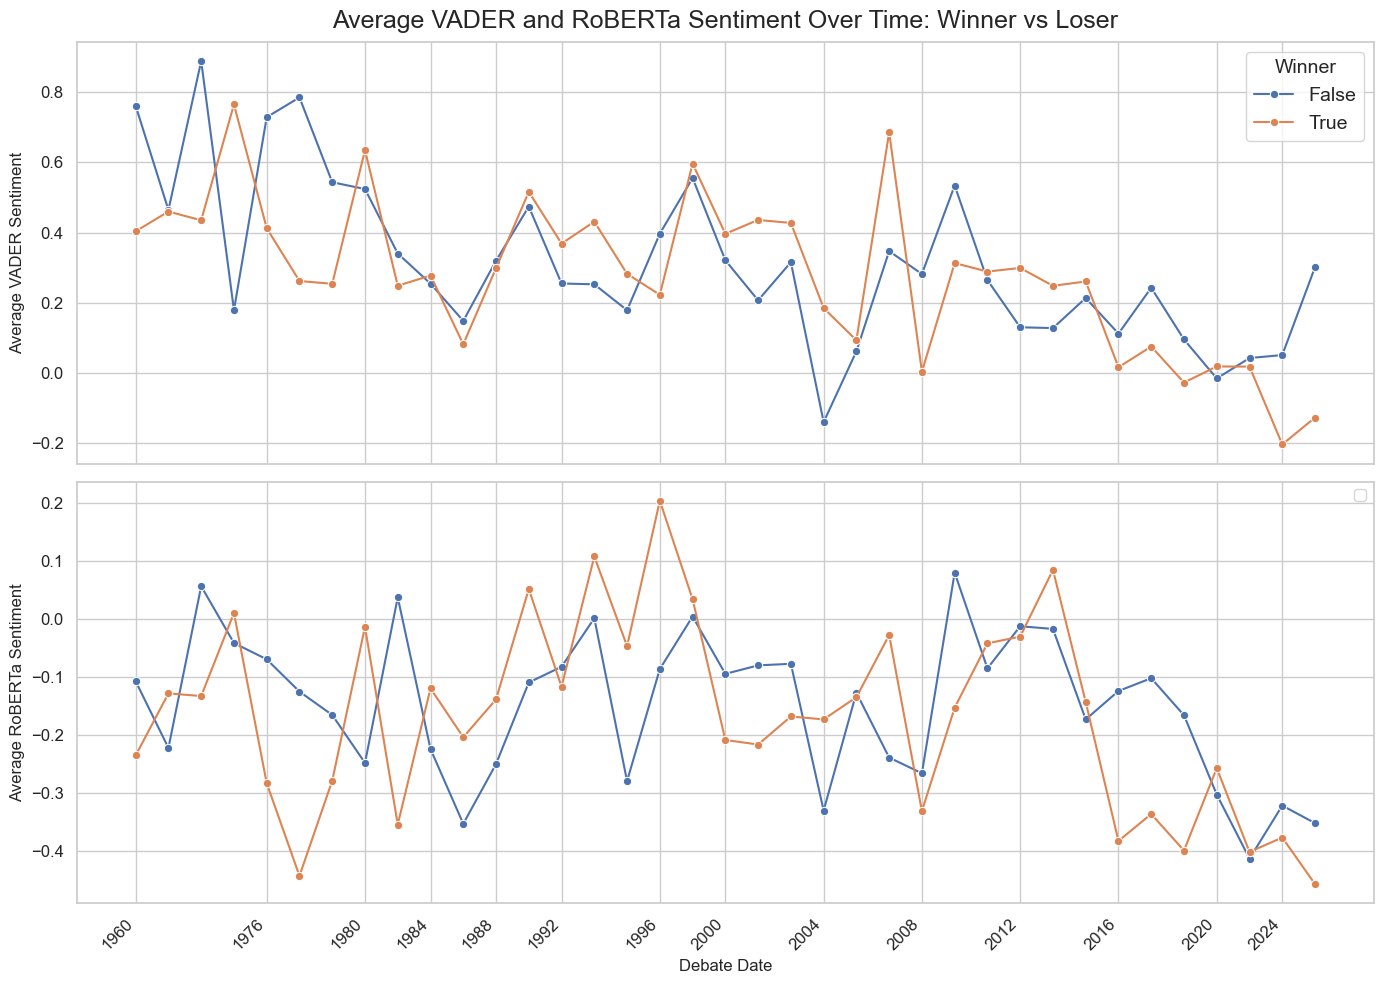

In [214]:
# Set global font size
sns.set(style='whitegrid')

# Create subplot
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# VADER plot
sns.lineplot(
    data=df_candidates_pres,
    x='date',
    y='vader_sentiment',
    hue='is_winner',
    errorbar=None,
    marker='o',
    ax=axes[0]
)
axes[0].set_title('Average VADER and RoBERTa Sentiment Over Time: Winner vs Loser', fontsize=18, pad=10)
axes[0].set_ylabel('Average VADER Sentiment', fontsize=12)
axes[0].legend(title='Winner', fontsize=14, title_fontsize=14)
axes[0].tick_params(axis='both', labelsize=12)
axes[0].grid(True)

# RoBERTa plot
sns.lineplot(
    data=df_candidates_pres,
    x='date',
    y='bert_sentiment',
    hue='is_winner',
    errorbar=None,
    marker='o',
    ax=axes[1]
)
axes[1].set_title('', fontsize=12)
axes[1].set_xlabel('Debate Date', fontsize=12)
axes[1].set_ylabel('Average RoBERTa Sentiment', fontsize=12)
axes[1].legend('')
axes[1].tick_params(axis='both', labelsize=12)
axes[1].grid(True)

# Set x-axis ticks to first available date in each decade
unique_dates = df_candidates_pres[['date', 'year']].drop_duplicates().sort_values('date')
ticks = unique_dates.groupby('year').first().reset_index()
tick_positions = ticks['date'].tolist()
tick_labels = ticks['year'].tolist()

axes[1].set_xticks(tick_positions)
axes[1].set_xticklabels(tick_labels, rotation=45, ha='right', fontsize=12)

plt.tight_layout()
plt.show()

In [202]:
df_display = df_candidates_pres[["debate_title", "actor", "dialogue", "vader_sentiment", "vader_label", "bert_sentiment", "bert_label", "diff_sentiment"]].sort_values(by=['diff_sentiment'], ascending=False).head(10).copy()
df_display['dialogue'] = df_display['dialogue'].apply(lambda x: x[:500] + '...' if len(x) > 500 else x)

display(df_display.style.set_properties(subset=['dialogue'], **{'white-space': 'pre-wrap'}))

,debate_title,actor,dialogue,vader_sentiment,vader_label,bert_sentiment,bert_label,diff_sentiment
3606,2016_Clinton Hillary_Trump_1,Trump,"And she doesnt say that, because shes got no business ability. We need heart. We need a lot of things. But you have to have some basic ability. And sadly, she doesnt have that. All of the things that shes talking about could have been taken care of during the last 10 years, lets say, while she had great power. But they werent taken care of. And if she ever wins this race, they wont be taken care of.",0.977400,positive,-0.930616,negative,1.908016
5222,2020_Biden_Trump_2,Trump,"First of all, Ive already done something that nobody thought was possible. Through the legislature, I terminated the individual mandate. That is the worst part of Obamacare, as we call it. The individual mandate where you have to pay a fortune for the privilege of not having to pay for bad health insurance. I terminated it; its gone. Now its in court, because Obamacare is no good. But then I made a decision, Run it as well as you can to my people, great people Run it as well as you can. I cou...",0.998000,positive,-0.897300,negative,1.895300
2644,2008_Mccain_Obama_3,Mccain,"Well, it is a terribly painful situation for Americans. Theyre seeing their premiums, their co-pays go up. Forty-seven million Americans are without health insurance in America today. And it really is the cost, the escalating costs of health care that are inflicting such pain on working families and people across this country. And I am convinced we need to do a lot of things. We need to put health care records online. The V.A. does that. That will that will reduce costs. We need to have more co...",0.986800,positive,-0.906585,negative,1.893385
464,1988_Bush Sr_Dukakis_1,Bush Sr,"I think weve seen a deterioration of values. I think for a while as a nation we condoned those things we should have condemned. For a while, as I recall, it even seems to me that there was talk of legalizing or decriminalizing marijuana and other drugs, and I think thats all wrong. So weve seen a deterioration in values, and one of the things that I think we should do about it in terms of cause is to instill values into the young people in our schools. We got away, we got into this feeling that ...",0.988300,positive,-0.902589,negative,1.890889
185,1976_Carter_Ford_3,Ford,"I believe that the uh American people have been turned off in this election, uh Mr. Maynard, for a variety of reasons. We have seen on Capitol Hill, in the Congress, uh a great many uh allegations of wrong-doing, of uh alleged immorality, uh those are very disturbing to the American people. They wonder how an elected representative uh can serve them and participate in such activities uh serving in the Congress of the United States. Yes, and Im certain many, many Americans were turned off...",0.983400,positive,-0.905465,negative,1.888865
438,1984_Mondale_Reagan_2,Mondale,"This is a very serious problem in our country, and it has to be dealt with. I object to that part of the Simpson-Mazzoli bill which I think is very unfair and would prove to be so. That is the part that requires employers to determine the citizenship of an employee before theyre hired. Im convinced that the result of this would be that people who are Hispanic, people who have different languages or speak with an accent, would find it difficult to be employed. I think thats wrong. Weve never had ...",0.985800,positive,-0.900771,negative,1.886571
2533,2008_Mccain_Obama_2,Obama,"Well, you know, Senator McCain, in the last debate and today, again, suggested that I dont understand. Its true. There are some things I dont understand. I dont understand how we ended up invading a country that had nothing to do with 9/11, while Osama Bin Laden and Al Qaeda are setting up base camps and safe havens to train terrorists to attack us. That was Senator McCains judgment and it was the wrong judgment. When Senator McCain was cheerleading the president to g

## Analysis of Trump

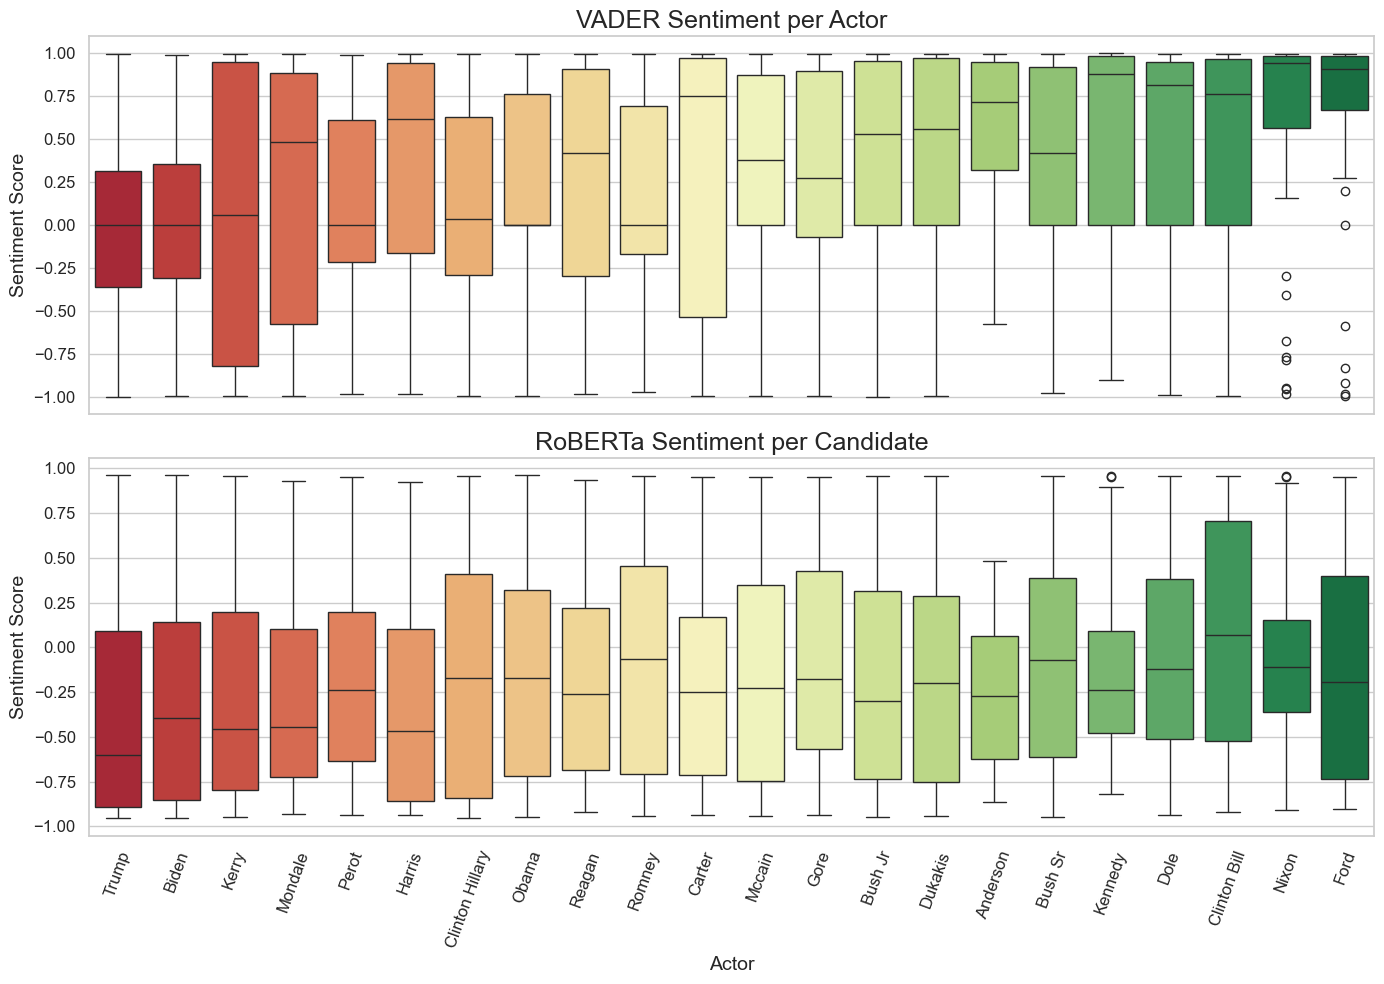

In [209]:
# Set the size for all labels, titles, and ticks
label_size = 14
title_size = 18
tick_size = 12

# Calculate mean sentiment per actor for consistent ordering
mean_vader = df_candidates_pres.groupby('actor')['vader_sentiment'].mean()
mean_bert = df_candidates_pres.groupby('actor')['bert_sentiment'].mean()

# Use average of both means to set a common actor order
mean_combined = ((mean_vader + mean_bert) / 2).sort_values()
actor_order = mean_combined.index


fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# VADER boxplot
sns.boxplot(
    data=df_pres_debate,
    x='actor',
    y='vader_sentiment',
    order=actor_order,
    palette='RdYlGn',
    ax=axes[0]
)
axes[0].set_title('VADER Sentiment per Actor', fontsize=title_size)
axes[0].set_ylabel('Sentiment Score', fontsize=label_size)
axes[0].tick_params(axis='x', rotation=70, labelsize=tick_size)
axes[0].tick_params(axis='y', labelsize=tick_size)

# BERT boxplot
sns.boxplot(
    data=df_pres_debate,
    x='actor',
    y='bert_sentiment',
    order=actor_order,
    palette='RdYlGn',
    ax=axes[1]
)
axes[1].set_title('RoBERTa Sentiment per Candidate', fontsize=title_size)
axes[1].set_xlabel('Actor', fontsize=label_size)
axes[1].set_ylabel('Sentiment Score', fontsize=label_size)
axes[1].tick_params(axis='x', rotation=70, labelsize=tick_size)
axes[1].tick_params(axis='y', labelsize=tick_size)

plt.tight_layout()
plt.show()

In [204]:
df_trump = df_candidates_pres[df_candidates_pres['actor']=='Trump']

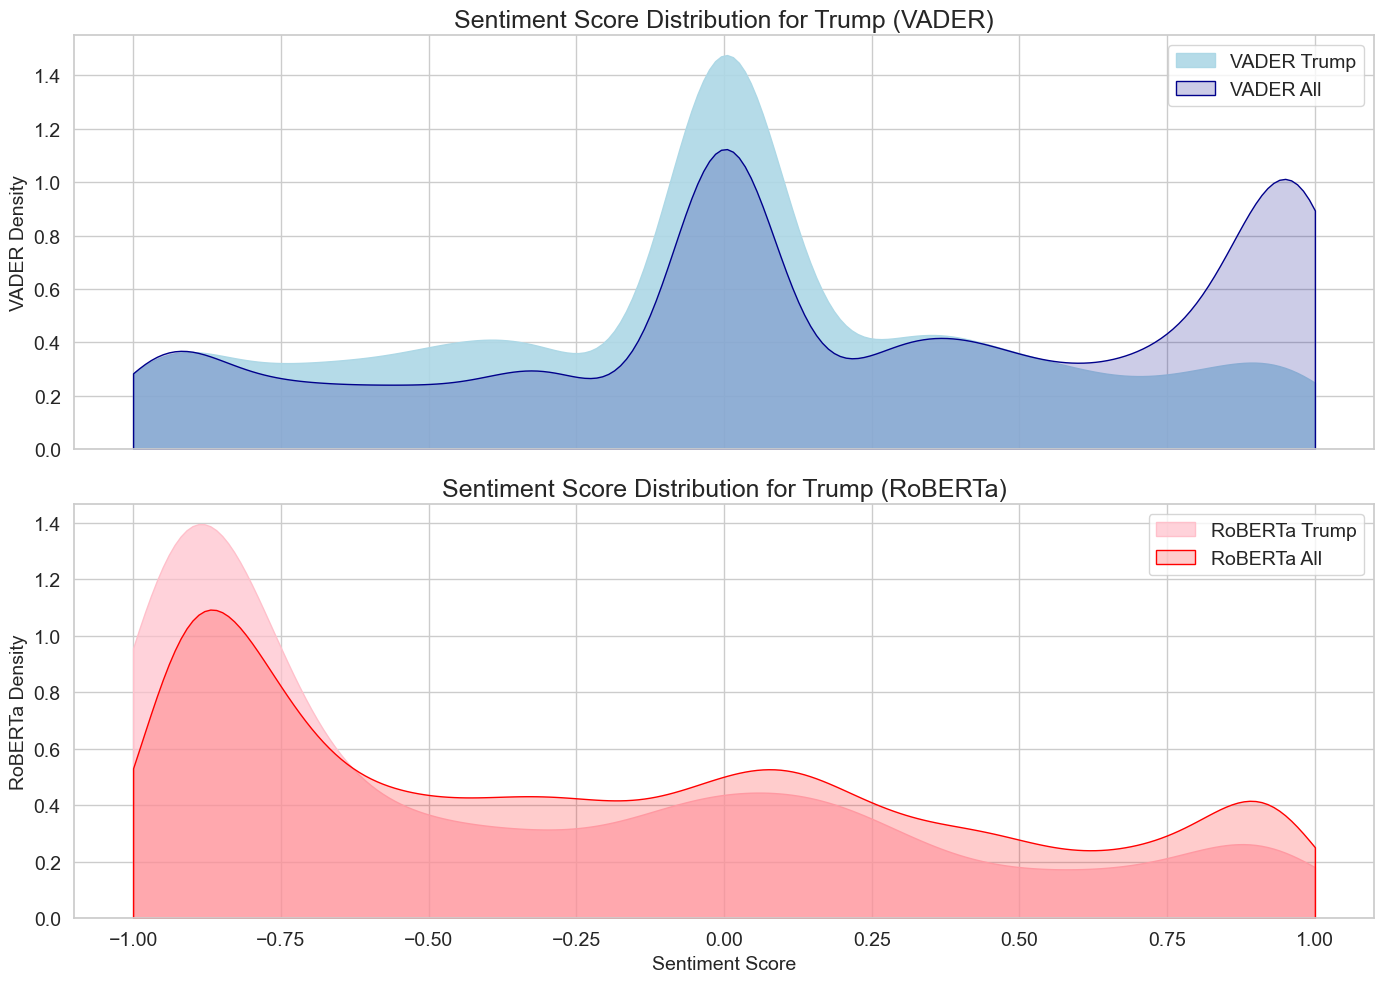

In [208]:
sns.set(style='whitegrid')

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# VADER
sns.kdeplot(
    df_trump['vader_sentiment'],
    label='VADER Trump',
    fill=True,
    color='lightblue',
    bw_adjust=0.75,
    alpha=0.9,
    clip=(-1, 1),
    ax=axes[0]
)
sns.kdeplot(
    df_candidates_pres['vader_sentiment'],
    label='VADER All',
    fill=True,
    color='darkblue',
    alpha=0.2,
    bw_adjust=0.75,
    clip=(-1, 1),
    ax=axes[0]
)
axes[0].set_title('Sentiment Score Distribution for Trump (VADER)', fontsize=18)
axes[0].set_ylabel('VADER Density', fontsize=14)
axes[0].tick_params(axis='both', labelsize=14)
axes[0].legend(fontsize=14, title_fontsize=14)
axes[0].grid(True)

# RoBERTa
sns.kdeplot(
    df_trump['bert_sentiment'],
    label='RoBERTa Trump',
    fill=True,
    color='pink',
    alpha=0.7,
    bw_adjust=0.75,
    clip=(-1, 1),
    ax=axes[1]
)
sns.kdeplot(
    df_candidates_pres['bert_sentiment'],
    label='RoBERTa All',
    fill=True,
    color='red',
    alpha=0.2,
    bw_adjust=0.75,
    clip=(-1, 1),
    ax=axes[1]
)
axes[1].set_title('Sentiment Score Distribution for Trump (RoBERTa)', fontsize=18)
axes[1].set_xlabel('Sentiment Score', fontsize=14)
axes[1].set_ylabel('RoBERTa Density', fontsize=14)
axes[1].tick_params(axis='both', labelsize=14)
axes[1].legend(fontsize=14, title_fontsize=14)
axes[1].grid(True)

plt.tight_layout()
plt.show()

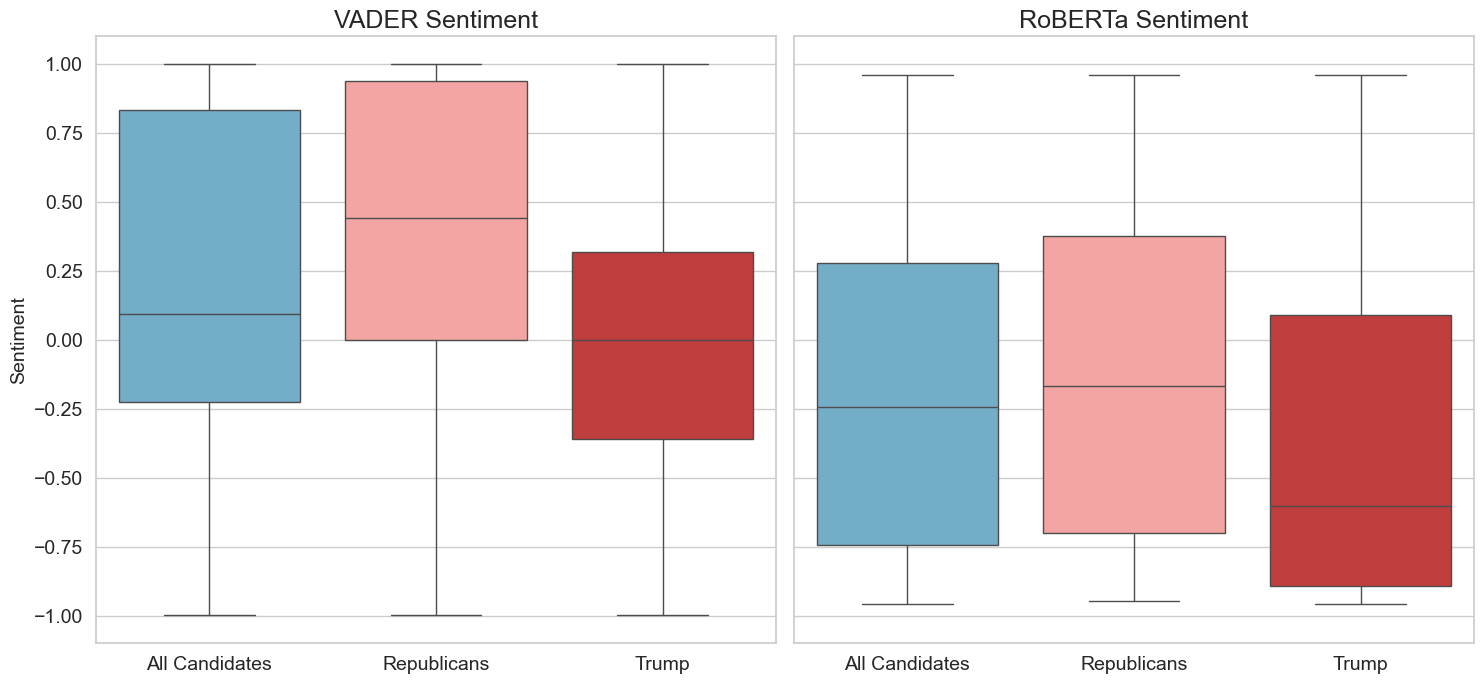

In [213]:
# Assign groups
df_candidates_pres['group'] = 'All Candidates'
df_candidates_pres.loc[df_candidates_pres['actor'] == 'Trump', 'group'] = 'Trump'
df_candidates_pres.loc[
    (df_candidates_pres['party'] == 'Republican') & 
    (df_candidates_pres['actor'] != 'Trump'),
    'group'
] = 'Republicans'

# Custom color palette
custom_palette = {
    'All Candidates': '#66b2d6',
    'Republicans': '#ff9896',
    'Trump': '#d62728'
}

# Set global font size
sns.set(style='whitegrid')

# Create side-by-side box plots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 7), sharey=True)

# VADER (left)
sns.boxplot(data=df_candidates_pres, x='group', y='vader_sentiment', palette=custom_palette, ax=axes[0])
axes[0].set_title('VADER Sentiment', fontsize=18)
axes[0].set_xlabel('', fontsize=14)
axes[0].set_ylabel('Sentiment', fontsize=14)
axes[0].tick_params(axis='both', labelsize=14)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0, ha='center')  #rotate to avoid overlap
axes[0].grid(True, axis='y')

# RoBERTa (right)
sns.boxplot(data=df_candidates_pres, x='group', y='bert_sentiment', palette=custom_palette, ax=axes[1])
axes[1].set_title('RoBERTa Sentiment', fontsize=18)
axes[1].set_xlabel('', fontsize=14)
axes[1].tick_params(axis='both', labelsize=14)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0, ha='center')  #rotate to avoid overlap
axes[1].grid(True, axis='y')

plt.tight_layout()
plt.show()

# Topic Modeling

## Preprocess Data specifically for LDA and LDASeqModel

In [25]:
# Initialize tools
tokenizer = TreebankWordTokenizer()
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Preprocessing text
def text_preprocess(text):
    if pd.isnull(text):
        return ""
    tokens = tokenizer.tokenize(text)
    filtered_tokens = [word.lower() for word in tokens if word.isalpha() and word.lower() not in stop_words]
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in filtered_tokens]
    return " ".join(lemmatized_tokens)
df_transcripts["preprocessed_text"] = df_transcripts["dialogue"].progress_apply(text_preprocess)

# Preview
df_transcripts[["dialogue", "preprocessed_text"]].head(10)

100%|██████████| 9933/9933 [00:05<00:00, 1820.38it/s]


,dialogue,preprocessed_text
0,"Mr. Smith, Mr. Nixon. In the election of 1860,...",smith election abraham lincoln said question w...
1,And now the opening statement by Vice Presiden...,opening statement vice president richard nixon
2,"Mr. Smith, Senator Kennedy. The things that Se...",smith senator thing senator kennedy said many ...
3,"Thank you, Mr. Nixon. That completes the openi...",thank completes opening statement candidate an...
4,"Senator, the Vice President in his campaign ha...",senator vice president campaign said naive tim...
5,"Well, the Vice President and I came to the Con...",well vice president came congress together ser...
6,"Mr. Nixon, would you like to comment on that s...",nixon would like comment statement
7,I have no comment.,comment
8,The next question: Mr. Novins.,next question novins
9,"Mr. Vice President, your campaign stresses the...",vice president campaign stress value eight yea...


In [26]:
# Function for Filtering NOUN, ADJ, PROPN
def keep_nouns_adjectives_spacy(text):
    if pd.isnull(text):
        return ""
    doc = nlp(text)
    return " ".join([token.text.lower() for token in doc if token.pos_ in {"NOUN", "ADJ", "PROPN"}])

df_transcripts["preprocessed_text"] = df_transcripts["preprocessed_text"].progress_apply(keep_nouns_adjectives_spacy)

100%|██████████| 9933/9933 [01:53<00:00, 87.30it/s] 


In [29]:
# Collect lowercase names from the data
actor_words_to_remove = set(df_transcripts['actor'].dropna().str.lower().str.strip())
first_names_to_remove = set(name.lower() for name in CANDIDATE_FIRST_NAMES.values())
names_to_remove = actor_words_to_remove.union(first_names_to_remove)
names_to_remove.update(["clinton", "bush"])  # extra catch-all

def remove_names(text):
    if pd.isnull(text):
        return text
    tokens = text.split()
    cleaned_tokens = [word for word in tokens if word.lower() not in names_to_remove]
    return " ".join(cleaned_tokens)

df_transcripts["preprocessed_text"] = df_transcripts["preprocessed_text"].progress_apply(remove_names)

100%|██████████| 9933/9933 [00:00<00:00, 205204.34it/s]


In [30]:
#Show top 300 words to check data cleanliness
all_text = " ".join(df_transcripts["preprocessed_text"].dropna())
words = all_text.split()
word_counts = Counter(words)
top_300_df = word_counts.most_common(300)
top_words=[word for word, _ in top_300_df]
pd.set_option('display.max_rows', 300)
top_300_df

[('president', 3854),
 ('people', 3375),
 ('tax', 1786),
 ('year', 1782),
 ('american', 1726),
 ('senator', 1570),
 ('country', 1529),
 ('state', 1507),
 ('time', 1394),
 ('thing', 1255),
 ('governor', 1236),
 ('job', 1021),
 ('united', 1016),
 ('way', 1002),
 ('vice', 999),
 ('america', 943),
 ('new', 894),
 ('government', 870),
 ('world', 849),
 ('good', 818),
 ('right', 808),
 ('last', 790),
 ('plan', 759),
 ('lot', 729),
 ('fact', 710),
 ('first', 693),
 ('health', 689),
 ('sure', 683),
 ('administration', 665),
 ('money', 665),
 ('care', 651),
 ('program', 625),
 ('family', 615),
 ('many', 607),
 ('security', 598),
 ('number', 585),
 ('issue', 573),
 ('war', 569),
 ('great', 548),
 ('minute', 545),
 ('work', 542),
 ('problem', 542),
 ('percent', 534),
 ('talk', 529),
 ('important', 525),
 ('policy', 520),
 ('nation', 514),
 ('kind', 513),
 ('economy', 505),
 ('business', 499),
 ('able', 498),
 ('next', 495),
 ('child', 489),
 ('federal', 489),
 ('know', 480),
 ('day', 470),
 ('cut

In [31]:
# Define exception list
exception_words = {
    "tax", "job", "right", "health", "money", "care", "family", "program",
    "work", "security", "war", "business", "economy", "child", "cut", "nuclear",
    "school", "military", "woman", "budget", "social", "energy", "economic", "life",
    "law", "dollar", "education", "deal", "rate", "ill", "middle", "support",
    "weapon", "system", "cost", "drug", "young", "decision", "company", "iraq",
    "troop", "foreign", "medicare", "help", "force", "course", "oil", "defense",
    "opportunity", "soviet", "deficit", "kid", "china", "iran", "control", "increase",
    "insurance", "income", "pay", "trade", "house", "case", "power", "credit",
    "community", "word", "peace", "union", "ally", "russia", "court", "growth",
    "debt", "freedom", "effort", "use", "border", "order", "chance", "class",
    "terrorist", "college", "teacher", "action", "threat", "parent", "strength",
    "crime", "afghanistan", "arm", "call", "gun", "inflation", "member", "clean",
    "unemployment", "top", "israel", "price", "benefit", "taxpayer", "market",
    "worker", "justice", "saddam", "housing", "investment", "safe", "fund", "east",
    "russian", "sanction", "abortion", "police", "love", "regard", "fight", "lower",
    "crisis", "human", "attack", "industry", "welfare"
}

# Compute frequent words to remove (excluding exceptions)
top_words_set = set(top_words)
words_to_remove = top_words_set - exception_words

# Clean function with filtering
def clean_with_exceptions(text):
    if pd.isnull(text):
        return ""
    tokens = text.split()
    filtered_tokens = [word for word in tokens if word.lower() not in words_to_remove]
    return " ".join(filtered_tokens)
    
df_transcripts["preprocessed_text"] = df_transcripts["preprocessed_text"].progress_apply(clean_with_exceptions)

# Preview result
df_transcripts[["actor", "dialogue", "preprocessed_text"]].head(10)

100%|██████████| 9933/9933 [00:00<00:00, 227676.25it/s]


,actor,dialogue,preprocessed_text
0,Kennedy,"Mr. Smith, Mr. Nixon. In the election of 1860,...",abraham lincoln direction freedom direction ro...
1,Smith,And now the opening statement by Vice Presiden...,opening
2,Nixon,"Mr. Smith, Senator Kennedy. The things that Se...",discus internal affair tremendous internationa...
3,Smith,"Thank you, Mr. Nixon. That completes the openi...",completes comment anothers correspondent corre...
4,Fleming,"Senator, the Vice President in his campaign ha...",naive
5,Kennedy,"Well, the Vice President and I came to the Con...",labor program advocate century woodrow wilson ...
6,Smith,"Mr. Nixon, would you like to comment on that s...",comment
7,Nixon,I have no comment.,comment
8,Smith,The next question: Mr. Novins.,
9,Novins,"Mr. Vice President, your campaign stresses the...",stress observer participant initiator


In [32]:
# Drop rows where preprocessed_text is empty or just whitespace
df_transcripts = df_transcripts[df_transcripts["preprocessed_text"].str.strip() != ""]
df_transcripts_candidates = df_transcripts[df_transcripts["is_candidate"] == True].copy()
df_transcripts[["actor", "dialogue", "preprocessed_text"]].head(10)

,actor,dialogue,preprocessed_text
0,Kennedy,"Mr. Smith, Mr. Nixon. In the election of 1860,...",abraham lincoln direction freedom direction ro...
1,Smith,And now the opening statement by Vice Presiden...,opening
2,Nixon,"Mr. Smith, Senator Kennedy. The things that Se...",discus internal affair tremendous internationa...
3,Smith,"Thank you, Mr. Nixon. That completes the openi...",completes comment anothers correspondent corre...
4,Fleming,"Senator, the Vice President in his campaign ha...",naive
5,Kennedy,"Well, the Vice President and I came to the Con...",labor program advocate century woodrow wilson ...
6,Smith,"Mr. Nixon, would you like to comment on that s...",comment
7,Nixon,I have no comment.,comment
9,Novins,"Mr. Vice President, your campaign stresses the...",stress observer participant initiator
10,Nixon,It would be rather difficult to cover them in ...,difficult foreign trip recommendation trip inc...


# Dominant Political Topics in US debates over Time

## Dynamic Topic Modeling using LDASeqModel

### Create Bag-of-Words Corpus and Dictionary for all statements

In [33]:
df_transcripts_candidates["tokens"] = df_transcripts_candidates["preprocessed_text"].dropna().apply(lambda x: x.split())

grouped = df_transcripts_candidates.groupby("year")["tokens"].apply(list).sort_index()

all_docs = [doc for year_docs in grouped for doc in year_docs]

timeslices = [len(year_docs) for year_docs in grouped]

dictionary = corpora.Dictionary(all_docs)

dictionary.filter_extremes(no_below=5)

corpus = [dictionary.doc2bow(text) for text in all_docs]

### Find optimal Number of Topics using Grid Search and UMass Coherence Score

In [36]:
def compute_umass_coherence_scores(corpus, dictionary, topic_range=range(3, 21), pass_number=50):
    """Compute UMass coherence scores for a range of topic numbers using LDA."""
    
    coherence_scores = []
    for num_topics in topic_range:
        lda_model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            passes=pass_number,
            random_state=42
        )
        coherence_model = CoherenceModel(
            model=lda_model,
            corpus=corpus,
            dictionary=dictionary,
            coherence='u_mass'
        )
        coherence = coherence_model.get_coherence()
        coherence_scores.append(coherence)
        print(f"Topics: {num_topics}, UMass Coherence: {coherence:.4f}")
    return coherence_scores

coherence_scores = compute_umass_coherence_scores(corpus=corpus,dictionary=dictionary)

Topics: 3, UMass Coherence: -2.3950
Topics: 4, UMass Coherence: -2.7079
Topics: 5, UMass Coherence: -3.0935
Topics: 6, UMass Coherence: -3.3181
Topics: 7, UMass Coherence: -3.4891
Topics: 8, UMass Coherence: -3.4568
Topics: 9, UMass Coherence: -4.4757
Topics: 10, UMass Coherence: -4.2802
Topics: 11, UMass Coherence: -4.2827
Topics: 12, UMass Coherence: -4.6184
Topics: 13, UMass Coherence: -5.3497
Topics: 14, UMass Coherence: -5.4816
Topics: 15, UMass Coherence: -5.4053
Topics: 16, UMass Coherence: -5.2060
Topics: 17, UMass Coherence: -5.8797
Topics: 18, UMass Coherence: -5.8169
Topics: 19, UMass Coherence: -5.9910
Topics: 20, UMass Coherence: -5.9321


In [92]:
def plot_topic_trends_over_time(ldaseq_model, all_docs=all_docs, grouped=grouped, title="Topic Trends Over Time"):
    """ Plots topic trends over time for a trained LdaSeqModel."""
    
    # Document-topic distributions from the trained DTM model
    doc_topic_dists = [ldaseq_model.doc_topics(i) for i in range(len(all_docs))]
    topic_df = pd.DataFrame(doc_topic_dists, columns=[f"Topic {i}" for i in range(ldaseq_model.num_topics)])

    years_per_doc = []
    for year, docs in grouped.items():
        years_per_doc.extend([year] * len(docs))
    topic_df["year"] = years_per_doc

    # Average topic proportions per year
    topic_trends = topic_df.groupby("year").mean()

    # Descriptive topic labels with top terms at time=0
    topic_labels = []
    for topic_id in range(ldaseq_model.num_topics):
        top_terms = ldaseq_model.print_topic(topic=topic_id, time=0, top_terms=10)
        label = f"Topic {topic_id}: " + ", ".join([term for term, _ in top_terms])
        topic_labels.append(label)

    plt.figure(figsize=(12, 6))
    for i, col in enumerate(topic_trends.columns):
        plt.plot(topic_trends.index, topic_trends[col], marker='o', label=topic_labels[i])

    plt.title(title, fontsize=16)
    plt.xlabel("Year", fontsize=14)
    plt.ylabel("Average Topic Proportion", fontsize=14)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Train the LDASeqModel with 3 Topics

In [101]:
np.seterr(divide='ignore', invalid='ignore')
ldaseq_3_topics = LdaSeqModel(
    corpus=corpus,
    time_slice=timeslices,
    id2word=dictionary,
    num_topics=3,
    initialize='gensim',
    random_state=42
)

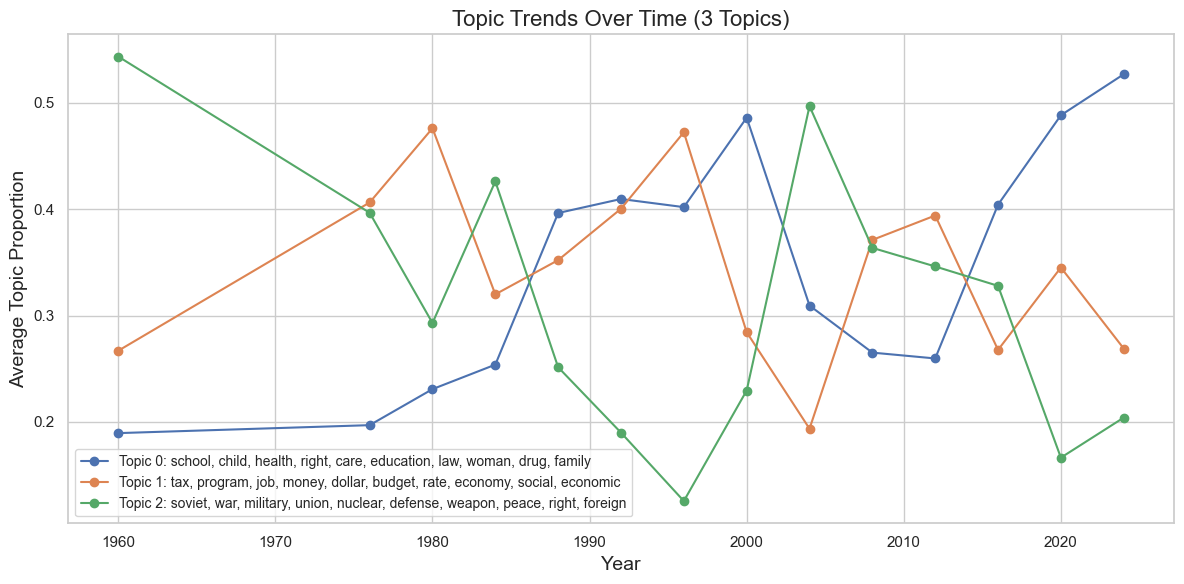

In [102]:
plot_topic_trends_over_time(ldaseq_3_topics, title="Topic Trends Over Time (3 Topics)")

### Train the LDASeqModel with 4 Topics

In [103]:
ldaseq_4_topics = LdaSeqModel(
    corpus=corpus,
    time_slice=timeslices,
    id2word=dictionary,
    num_topics=4,
    initialize='gensim',
    random_state=42
)

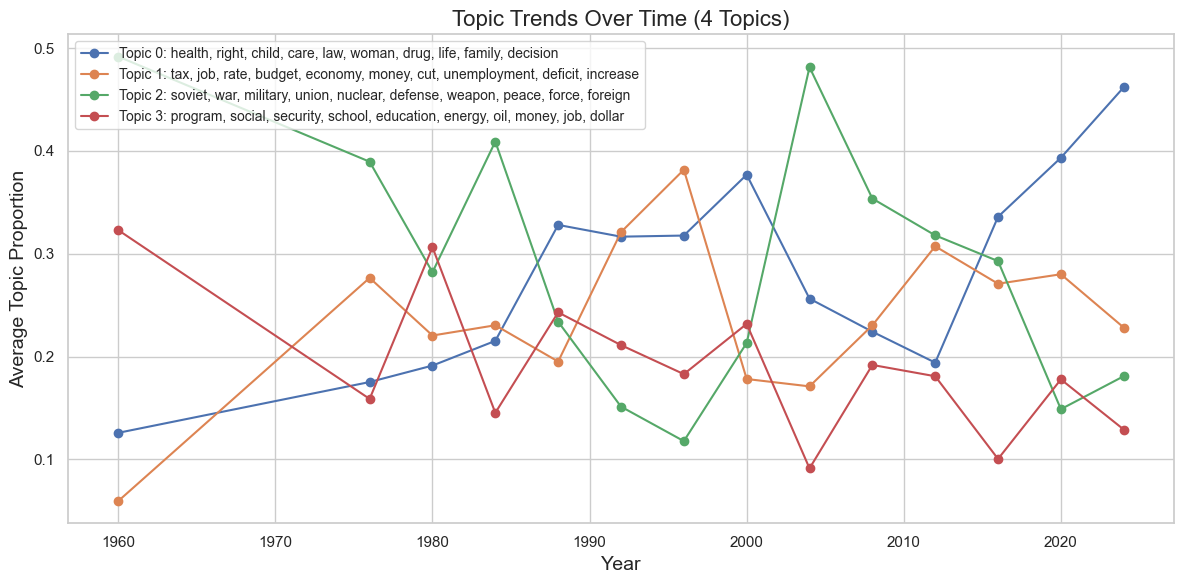

In [108]:
plot_topic_trends_over_time(ldaseq_4_topics, title="Topic Trends Over Time (4 Topics)")

### Train the LDASeqModel with 5 Topics

In [104]:
ldaseq_5_topics = LdaSeqModel(
    corpus=corpus,
    time_slice=timeslices,
    id2word=dictionary,
    num_topics=5,
    initialize='gensim',
    random_state=42
)

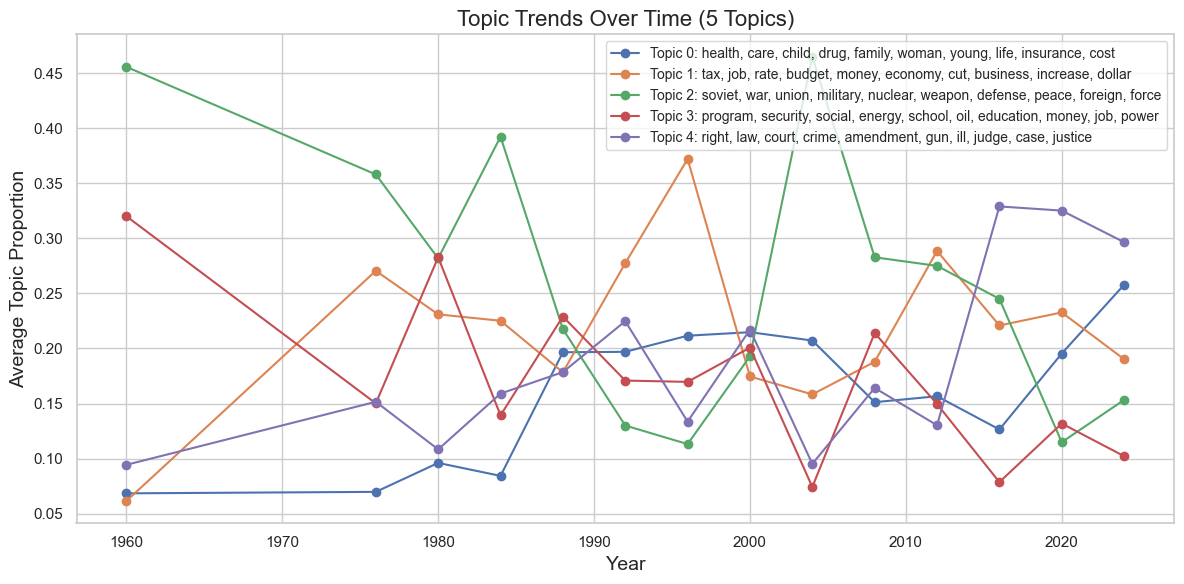

In [107]:
plot_topic_trends_over_time(ldaseq_5_topics, title="Topic Trends Over Time (5 Topics)")

In [ ]:
topic_id = 2      
top_n = 15        
target_years = [1960, 2004, 2024]  

years = list(grouped.index)

topic2_words_selected_years = {}

for t, year in enumerate(years):
    if year in target_years:
        terms = ldaseq_5_topics.print_topic(topic=topic_id, time=t, top_terms=top_n)
        topic2_words_selected_years[year] = [term for term, _ in terms]

topic2_selected_df = pd.DataFrame.from_dict(topic2_words_selected_years, orient='index').transpose()
topic2_selected_df.index.name = "Top Term Rank"

print(topic2_selected_df)

                    1960         2004       2024
Top Term Rank                                   
0                 soviet          war        war
1                    war      nuclear    nuclear
2                  union         iraq   military
3               military     military       iran
4                nuclear        troop     russia
5                 weapon       weapon       iraq
6                defense        right      troop
7                  peace         iran     weapon
8                foreign        force      right
9                  force     security      force
10              strength         ally       ally
11                 right    terrorist   security
12               freedom  afghanistan  terrorist
13             communist       russia      putin
14              security      foreign     israel


## Topic Modeling using BERTopic Over Time

Although BERTopic is generally robust to raw text and does not require extensive preprocessing, our initial results motivated us to apply light preprocessing and deploy KeyBERT to help the model better focus on relevant topics.

In [64]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [65]:
docs_cleaned=df_transcripts_candidates["dialogue"].dropna().tolist()

# Fit TF-IDF vectorizer to get top 300 words
tfidf = TfidfVectorizer(max_features=300)
tfidf.fit(docs_cleaned)
top_300_vocab = tfidf.get_feature_names_out()

# Create a new vectorizer restricted to these top 300 words
tfidf_vectorizer= TfidfVectorizer(vocabulary=top_300_vocab)

In [66]:
topic_model = BERTopic(embedding_model=embedding_model, vectorizer_model=tfidf_vectorizer, verbose=True)

In [67]:
topics, probs = topic_model.fit_transform(docs_cleaned)
df_transcripts_candidates['topic'] = topics

topic_model.generate_topic_labels(nr_words=1)

2025-05-29 15:24:12,078 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/140 [00:00<?, ?it/s]

2025-05-29 15:24:34,123 - BERTopic - Embedding - Completed ✓
2025-05-29 15:24:34,125 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-05-29 15:25:20,510 - BERTopic - Dimensionality - Completed ✓
2025-05-29 15:25:20,513 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-29 15:25:20,722 - BERTopic - Cluster - Completed ✓
2025-05-29 15:25:20,729 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-05-29 15:25:21,220 - BERTopic - Representation - Completed ✓


['-1_the',
 '0_medicare',
 '1_and',
 '2_energy',
 '3_tax',
 '4_education',
 '5_budget',
 '6_life',
 '7_jobs',
 '8_she',
 '9_re',
 '10_country',
 '11_nuclear',
 '12_people',
 '13_me',
 '14_law',
 '15_got',
 '16_law',
 '17_dollars',
 '18_taxes',
 '19_nuclear',
 '20_iraq',
 '21_troops',
 '22_weapons',
 '23_middle',
 '24_was',
 '25_uh',
 '26_john',
 '27_uh',
 '28_economy',
 '29_family',
 '30_important',
 '31_military',
 '32_voted',
 '33_000',
 '34_uh',
 '35_defense',
 '36_ill',
 '37_thats',
 '38_against',
 '39_we',
 '40_young',
 '41_troops',
 '42_did',
 '43_senator',
 '44_world',
 '45_nuclear',
 '46_my',
 '47_energy',
 '48_women',
 '49_congress',
 '50_women',
 '51_he',
 '52_time',
 '53_iraq',
 '54_jobs',
 '55_wants',
 '56_troops',
 '57_policy',
 '58_america',
 '59_thank',
 '60_between',
 '61_must',
 '62_im',
 '63_obama',
 '64_re',
 '65_john',
 '66_he',
 '67_the']

In [90]:
def plot_bertopic_trends(topic_model, df, top_n=10, title="Top Debate Topics Over Time",
                         selected_topics=None, proportions=False, topic_col="topic", year_col="year",
                         n_terms=7):
    """
    Smaller version of the BERTopic trend plot with legend underneath.
    """
    topic_info = topic_model.get_topic_info()

    if selected_topics is not None:
        top_topics = [t for t in selected_topics if t in topic_info['Topic'].values and t != -1]
    else:
        top_topics = topic_info[topic_info.Topic != -1].head(top_n)['Topic'].tolist()

    years = sorted(df[year_col].unique())
    topic_by_year = []

    for topic in top_topics:
        if proportions:
            proportions_list = []
            for year in years:
                total_docs = len(df[df[year_col] == year])
                topic_docs = len(df[(df[topic_col] == topic) & (df[year_col] == year)])
                proportion = topic_docs / total_docs if total_docs > 0 else 0
                proportions_list.append(proportion)
            topic_by_year.append(proportions_list)
        else:
            counts = [len(df[(df[topic_col] == topic) & (df[year_col] == year)]) for year in years]
            topic_by_year.append(counts)

    colors = matplotlib.colormaps['tab20'].colors if len(top_topics) <= 20 else matplotlib.colormaps['hsv'].colors

    topic_labels = {
        topic: f"Topic {topic}: " + ", ".join([term for term, _ in topic_model.get_topic(topic)[:n_terms]])
        for topic in top_topics
    }

    # Smaller figure
    plt.figure(figsize=(9, 16.5))
    for i, topic in enumerate(top_topics):
        label = topic_labels[topic]
        plt.plot(
            years, topic_by_year[i],
            marker='o',
            linewidth=2,
            color=colors[i % len(colors)],
            label=label
        )

    plt.xlabel("Year", fontsize=18)
    plt.ylabel("Proportion" if proportions else "Mentions", fontsize=18)
    plt.title(title, fontsize=20)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, -0.25),
        ncol=1,
        fontsize=14,
        title_fontsize=16
    )
    plt.tight_layout(rect=[0, 0.3, 1, 1])
    plt.grid(True, alpha=0.3)
    plt.show()

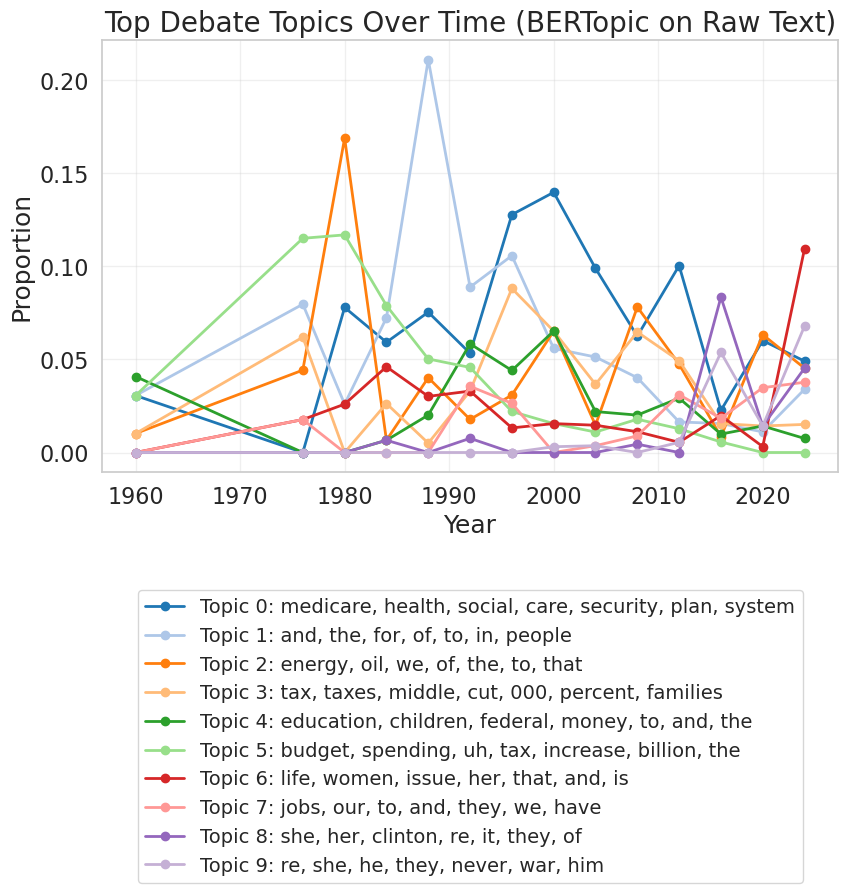

In [91]:
plot_bertopic_trends(
    topic_model, 
    df_transcripts_candidates, 
    top_n=10, 
    title="Top Debate Topics Over Time (BERTopic on Raw Text)", 
    proportions=True,
)

As evident, BERTopic generated several topics that were not directly relevant to our research question on the evolution of dominant political themes over time. This prompted us to incorporate KeyBERT and remove "domain-specific" stopwords to better align the topics with our analytical focus.

### Remove domain-specific stopwords

In [108]:
def get_names_to_remove(df):
    assert 'actor' in df.columns, "DataFrame must contain 'actor' column"
    assert 'first_name' in df.columns, "DataFrame must contain 'first_name' column"
    
    actor_words_to_remove = set(df['actor'].dropna().str.lower().str.strip())
    first_names_to_remove = set(df['first_name'].dropna().str.lower().str.strip())

    names_to_remove = actor_words_to_remove.union(first_names_to_remove)
    names_to_remove.update(["clinton", "bush"])
    return names_to_remove

def remove_political_stopwords(text, names_to_remove):
    assert isinstance(names_to_remove, set), "names_to_remove must be a set"
    assert isinstance(text, str), "text must be a string"
    
    political_stopwords = {
    # Titles
    "president", "senator", "governor", "representative", "congressman", "congresswoman",
    "mayor", "minister", "secretary", "chancellor", "ambassador", "prime", "premier",
    "chairman", "chairwoman", "chief", "officer", "general", "director", "leader", "commander",

    # General political fillers
    "people", "citizens", "citizen", "nation", "country", "government", "state", "party", "administration",
    "public", "leaders", "movement", "society", "officials", "office", "lawmakers","senate", "house", "congress", 
    "legislature", "parliament", "assembly",

    # Time references
    "year", "day", "month", "time", "decade", "century", "years", "minute", "minutes", "hour", "hours", "tonight",
    "today", "tomorrow", "yesterday", "week", "weeks", "decades", "centuries",

    # Geopolitical/administrative
    "state", "states", "district", "region", "city", "capital", "province", "territory", "america", "american",

    # Procedural terms
    "vote", "election", "voter", "campaign", "resolution", "policy", "platform", "debate"}
    
    terms_to_remove = set(political_stopwords).union(names_to_remove)
    
    if pd.isnull(text):
        return ""
    tokens = text.split()
    filtered_tokens = [word for word in tokens if not any(rem in word.lower() for rem in terms_to_remove)]
    filtered_tokens = [word for word in filtered_tokens if len(word) > 2]  # Remove short words
    return " ".join(filtered_tokens)

In [109]:
names_to_remove= get_names_to_remove(df_transcripts_candidates)

df_transcripts_candidates['preprocessed_text_BERTopic'] = df_transcripts_candidates['dialogue'].progress_apply(remove_political_stopwords, args=(names_to_remove,))
df_transcripts_candidates = df_transcripts_candidates[df_transcripts_candidates['preprocessed_text_BERTopic'].str.len() > 10]

docs = df_transcripts_candidates['preprocessed_text_BERTopic'].tolist()

100%|██████████| 4387/4387 [00:11<00:00, 375.34it/s] 


### Apply KeyBERT for Keywords Extraction

In [ ]:
kw_model = KeyBERT()
keywords = []

for doc in tqdm(docs, desc="Extracting keywords"):
    kw = kw_model.extract_keywords(doc, stop_words="english", top_n=5, use_maxsum=True)
    keywords.append(kw)

Extracting keywords:   0%|          | 0/4367 [00:00<?, ?it/s]

In [101]:
vocab = list(set([kw for kws in keywords for kw, _ in kws]))

vectorizer_model = CountVectorizer(vocabulary=vocab)

topic_model = BERTopic(embedding_model=embedding_model, vectorizer_model=vectorizer_model, verbose=True)

### Apply BERTopic again

In [102]:
topics, probs = topic_model.fit_transform(docs)
df_transcripts_candidates['topic'] = topics

topic_model.generate_topic_labels(nr_words=1)

2025-05-29 17:17:15,735 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/138 [00:00<?, ?it/s]

2025-05-29 17:31:16,433 - BERTopic - Embedding - Completed ✓
2025-05-29 17:31:16,435 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-05-29 17:31:46,696 - BERTopic - Dimensionality - Completed ✓
2025-05-29 17:31:46,709 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-29 17:31:46,902 - BERTopic - Cluster - Completed ✓
2025-05-29 17:31:46,909 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-05-29 17:31:47,345 - BERTopic - Representation - Completed ✓


['-1_going',
 '0_tax',
 '1_energy',
 '2_thank',
 '3_china',
 '4_schools',
 '5_health',
 '6_medicare',
 '7_shes',
 '8_abortion',
 '9_iran',
 '10_nice',
 '11_border',
 '12_vice',
 '13_deficit',
 '14_black',
 '15_soviet',
 '16_street',
 '17_dollars',
 '18_social',
 '19_afghanistan',
 '20_world',
 '21_vaccine',
 '22_syria',
 '23_court',
 '24_cities',
 '25_guns',
 '26_green',
 '27_economy',
 '28_israel',
 '29_returns',
 '30_nuclear',
 '31_cages',
 '32_vladimir',
 '33_susan',
 '34_cuba',
 '35_crosstalk',
 '36_inaudible',
 '37_elaine',
 '38_russia',
 '39_drug',
 '40_ballots',
 '41_ballots',
 '42_defense',
 '43_intelligence',
 '44_saddam',
 '45_quotas',
 '46_georgia',
 '47_nonsense',
 '48_lebanon',
 '49_milosevic',
 '50_iraq',
 '51_faith',
 '52_senator',
 '53_military',
 '54_pakistan',
 '55_fbi',
 '56_open',
 '57_korea',
 '58_idea',
 '59_islands',
 '60_foundation',
 '61_marriage',
 '62_business',
 '63_incorrect',
 '64_women',
 '65_farmers',
 '66_patriotism',
 '67_calendar',
 '68_work',
 '69_we

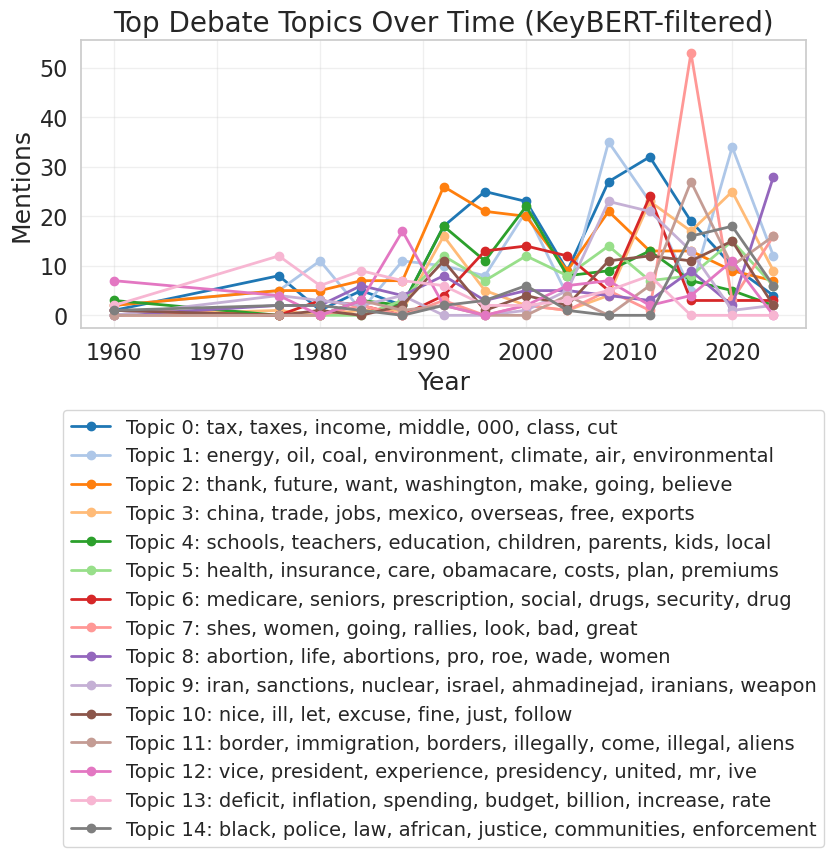

In [103]:
plot_bertopic_trends(topic_model, df_transcripts_candidates, top_n=15, title="Top Debate Topics Over Time (KeyBERT-filtered)")

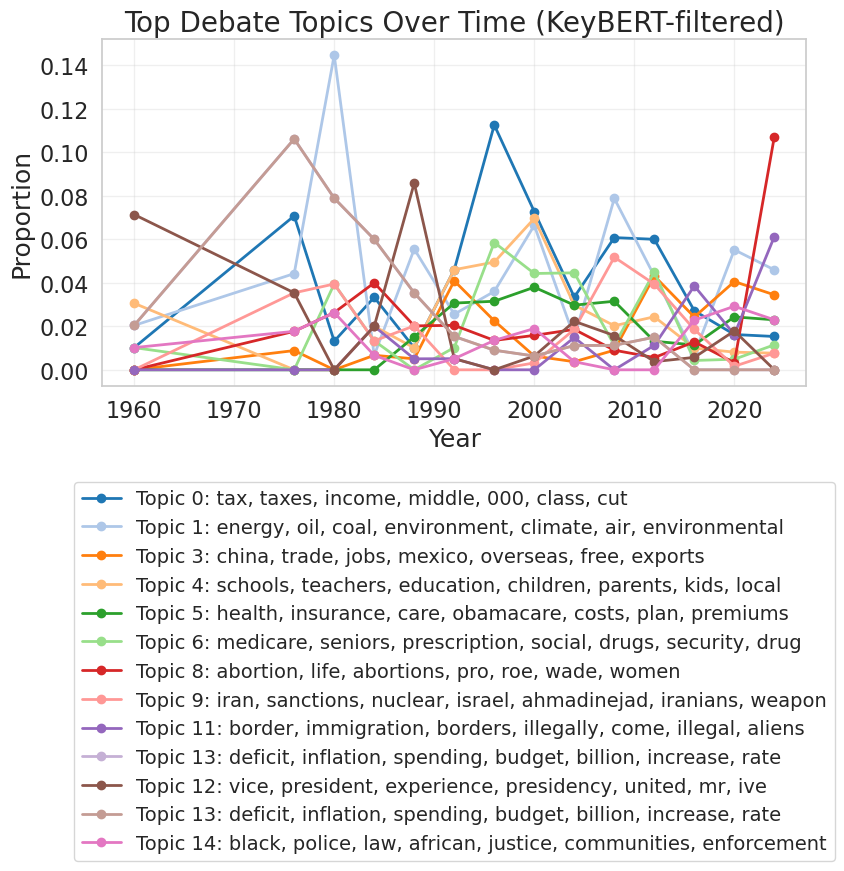

In [105]:
plot_bertopic_trends(topic_model, df_transcripts_candidates,selected_topics=[0 ,1, 3, 4, 5, 6, 8, 9, 11, 13, 12, 13, 14],
proportions=True, title="Top Debate Topics Over Time (KeyBERT-filtered)")

## LDA (Comparing Trump to other Candidates)

### Train the LDA Model on Candidates Statements

In [37]:
def train_and_print_lda(corpus, dictionary, num_topics, passes=3000, topn=10):
    """
    Train an LDA model and print topics.
    """
    lda_model = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=num_topics,
        passes=passes,
        random_state=42,
    )
    for i in range(lda_model.num_topics):
        print(f"Topic {i}:")
        print(lda_model.print_topic(i, topn=topn))
        print()
    return lda_model

### Load LDA Model and display the Topics created

In [38]:
lda_model = train_and_print_lda(corpus, dictionary, num_topics=5, passes=3000)

Topic 0:
0.038*"care" + 0.036*"health" + 0.022*"child" + 0.022*"family" + 0.021*"woman" + 0.020*"drug" + 0.016*"young" + 0.014*"insurance" + 0.011*"kid" + 0.009*"medicare"

Topic 1:
0.084*"tax" + 0.028*"job" + 0.022*"economy" + 0.022*"cut" + 0.020*"business" + 0.018*"money" + 0.016*"family" + 0.014*"rate" + 0.013*"pay" + 0.012*"china"

Topic 2:
0.027*"war" + 0.017*"military" + 0.016*"nuclear" + 0.012*"weapon" + 0.011*"iran" + 0.011*"iraq" + 0.011*"russia" + 0.011*"troop" + 0.010*"force" + 0.009*"soviet"

Topic 3:
0.020*"job" + 0.019*"energy" + 0.019*"program" + 0.019*"social" + 0.017*"security" + 0.016*"money" + 0.014*"school" + 0.014*"oil" + 0.013*"education" + 0.010*"budget"

Topic 4:
0.025*"law" + 0.018*"court" + 0.017*"right" + 0.013*"border" + 0.012*"justice" + 0.011*"gun" + 0.011*"crime" + 0.010*"case" + 0.010*"criminal" + 0.010*"police"



### Assign Groupings for Analysis of Topics between Trump and other Candidate Groupings

In [39]:
df_transcripts_candidates['grouping'] = df_transcripts_candidates['party']
df_transcripts_candidates.loc[df_transcripts_candidates['actor'] == 'Trump', 'grouping'] = 'Trump'
df_transcripts_candidates.loc[
    (~df_transcripts_candidates['VP_debate']) & 
    (df_transcripts_candidates['party'] == 'Democratic') & 
    (df_transcripts_candidates['year'] >= 2016), 'grouping'
] = 'Trump Opponents'
df_transcripts_candidates.loc[df_transcripts_candidates['grouping'] == 'Republican', 'grouping'] = 'Other Republicans'
df_transcripts_candidates.loc[df_transcripts_candidates['grouping'] == 'Democratic', 'grouping'] = 'Other Democrats'

df_transcripts_candidates

,debate_title,date,year,actor,first_name,dialogue,is_candidate,party,is_winner,VP_debate,is_incumbent,word_count,preprocessed_text,tokens,grouping
0,1960_Kennedy_Nixon_1,1960-09-26,1960,Kennedy,John,"Mr. Smith, Mr. Nixon. In the election of 1860,...",True,Democratic,True,False,False,1249,abraham lincoln direction freedom direction ro...,"[abraham, lincoln, direction, freedom, directi...",Other Democrats
2,1960_Kennedy_Nixon_1,1960-09-26,1960,Nixon,Richard,"Mr. Smith, Senator Kennedy. The things that Se...",True,Republican,False,False,False,1382,discus internal affair tremendous internationa...,"[discus, internal, affair, tremendous, interna...",Other Republicans
5,1960_Kennedy_Nixon_1,1960-09-26,1960,Kennedy,John,"Well, the Vice President and I came to the Con...",True,Democratic,True,False,False,186,labor program advocate century woodrow wilson ...,"[labor, program, advocate, century, woodrow, w...",Other Democrats
7,1960_Kennedy_Nixon_1,1960-09-26,1960,Nixon,Richard,I have no comment.,True,Republican,False,False,False,4,comment,[comment],Other Republicans
10,1960_Kennedy_Nixon_1,1960-09-26,1960,Nixon,Richard,It would be rather difficult to cover them in ...,True,Republican,False,False,False,270,difficult foreign trip recommendation trip inc...,"[difficult, foreign, trip, recommendation, tri...",Other Republicans
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9922,2024_Vance_Walz_VP,2024-10-01,2024,Walz,Tim,Sorry.,True,Democratic,False,True,False,1,sorry,[sorry],Other Democrats
9923,2024_Vance_Walz_VP,2024-10-01,2024,Vance,J.D.,That's not fire in a crowded theater. That is ...,True,Republican,True,True,False,22,fire,[fire],Other Republicans
9925,2024_Vance_Walz_VP,2024-10-01,2024,Walz,Tim,"Please. Yeah, well, I don't run Facebook. What...",True,Democratic,False,True,False,183,see shocked decision concerned firewall firewa...,"[see, shocked, decision, concerned, firewall, ...",Other Democrats
9928,2024_Vance_Walz_VP,2024-10-01,2024,Walz,Tim,"Well, thank you, Senator Vance. Thank you to C...",True,Democratic,False,True,False,391,cbs miss dancing star surprised coalition bern...,"[cbs, miss, dancing, star, surprised, coalitio...",Other Democrats


### Display the Topic Proportions of Trump and other Candidate Groupings

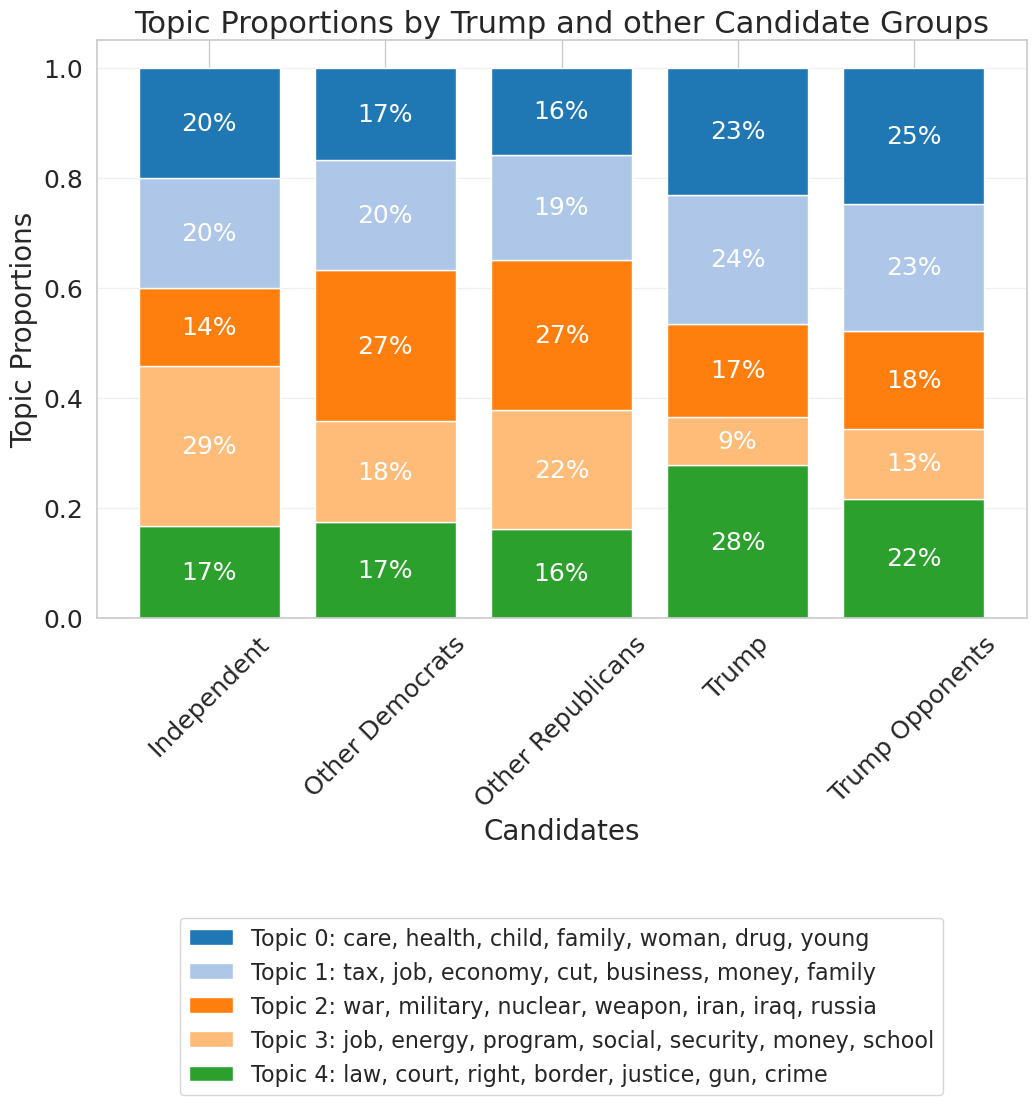

In [89]:
def plot_lda_by_category(lda_model, df, top_n=10, title="Topic Proportions by Trump and other Candidate Groups", 
                         selected_topics=None, proportions=True, topic_col="topic_lda", 
                         category_col="grouping", drop_values=None, n_terms=7):
    """
    Smaller version of the stacked bar plot (proportions preserved).
    """
    # Generate topic → label mapping
    topic_labels = {
        topic: f"Topic {topic}: " + ", ".join([word for word, _ in lda_model.show_topic(topic, topn=n_terms)])
        for topic in range(lda_model.num_topics)
    }

    topics = list(topic_labels.keys())
    categories = sorted(df[category_col].dropna().unique())

    if drop_values:
        categories = [cat for cat in categories if cat not in drop_values]

    topic_counts = {topic: [] for topic in topics}

    for category in categories:
        category_df = df[df[category_col] == category]
        total_docs = len(category_df)

        for topic in topics:
            count = len(category_df[category_df[topic_col] == topic])
            value = count / total_docs if proportions and total_docs > 0 else count
            topic_counts[topic].append(value)

    # Convert to DataFrame for plotting
    plot_df = pd.DataFrame(topic_counts, index=categories)

    # Plotting
    plt.figure(figsize=(12, 7.5))  # Smaller version of (16, 10)
    bar_bottoms = [0] * len(categories)
    bar_handles = []
    bar_labels = []

    for i, topic in reversed(list(enumerate(topics))):
        values = plot_df[topic]
        label = topic_labels[topic]
        bars = plt.bar(
            categories, values, bottom=bar_bottoms,
            color=plt.get_cmap('tab20')(i % 20),
            label=label
        )
        bar_handles.append(bars[0])
        bar_labels.append(label)

        for j, val in enumerate(values):
            if val > 0.01:
                y_pos = bar_bottoms[j] + val / 2
                display_val = f"{int(round(val * 100))}%"
                plt.text(j, y_pos, display_val, ha='center', va='center', fontsize=18, color='white')

        bar_bottoms = [b + v for b, v in zip(bar_bottoms, values)]

    plt.xlabel("Candidates", fontsize=20)
    plt.ylabel("Topic Proportions", fontsize=20)
    plt.title(title, fontsize=22)
    plt.xticks(rotation=45, fontsize=18)
    plt.yticks(fontsize=18)

    plt.legend(
        handles=bar_handles[::-1],
        labels=bar_labels[::-1],
        loc='upper center',
        bbox_to_anchor=(0.5, -0.5),
        ncol=1,
        fontsize=16,
        title_fontsize=18
    )

    plt.tight_layout(rect=[0, 0.4, 1, 1])
    plt.grid(axis='y', alpha=0.3)
    plt.show()

plot_lda_by_category(lda_model, df_transcripts_candidates, top_n=10, title="Topic Proportions by Trump and other Candidate Groups", 
                         selected_topics=None, proportions=True, topic_col="topic_lda", 
                         category_col="grouping", drop_values=None, n_terms=7)

## Trump Topic Modeling with BERTopic

In [107]:
def print_bertopic_terms_by_category(topic_model, df, top_n=10, selected_topics=None,
                                     topic_col="topic", category_col="grouping",
                                     drop_values=None, n_terms=7):
    """
    Print one PrettyTable per category for BERTopic results.
    Each row corresponds to a topic, with columns for:
    - Topic ID
    - Full Topic Label
    - Top N terms (comma-separated)
    """
    topic_info = topic_model.get_topic_info()

    # Define which topics to include
    if selected_topics is not None:
        top_topics = [t for t in selected_topics if t in topic_info['Topic'].values and t != -1]
    else:
        top_topics = topic_info[topic_info.Topic != -1].head(top_n)['Topic'].tolist()

    # Get valid groupings
    categories = sorted(df[category_col].dropna().unique())
    if drop_values:
        categories = [cat for cat in categories if cat not in drop_values]

    # Print table per category
    for category in categories:
        category_df = df[df[category_col] == category]

        table = PrettyTable()
        table.title = f"Top BERTopic Terms in Category: {category}"
        table.field_names = ["Topic ID", "Full Label", "Top Terms"]

        for topic in top_topics:
            topic_df = category_df[category_df[topic_col] == topic]
            if not topic_df.empty:
                label = f"Topic {topic}: " + ", ".join([term for term, _ in topic_model.get_topic(topic)[:n_terms]])
                terms = topic_model.get_topic(topic)
                top_terms = [term for term, _ in terms[:n_terms]]
                table.add_row([topic, label, ", ".join(top_terms)])

        if len(table._rows) > 0:
            print(table)

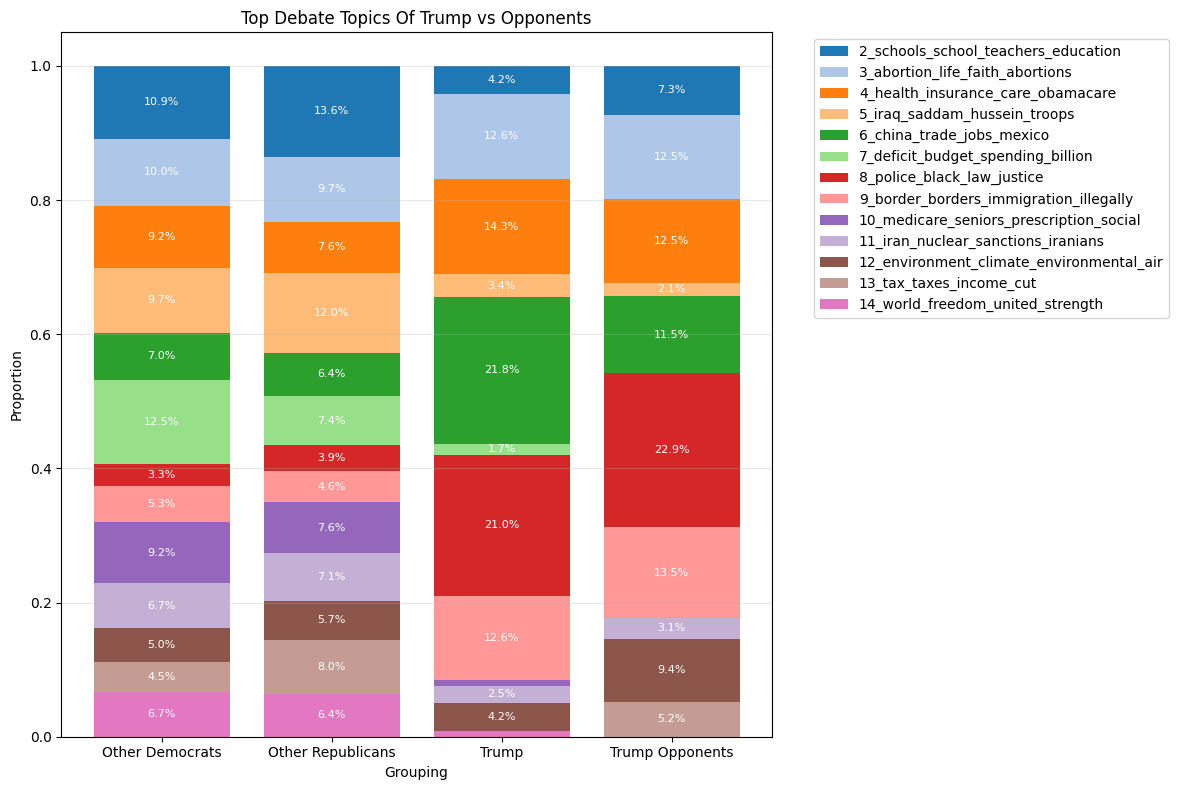

+-------------------------------------------------------------------------------------------------------------------------------------------------------+
|                                                    Top BERTopic Terms in Category: Other Democrats                                                    |
+----------+------------------------------------------+-------------------------------------------------------------------------------------------------+
| Topic ID |                  Label                   |                                            Top Terms                                            |
+----------+------------------------------------------+-------------------------------------------------------------------------------------------------+
|    2     |   2_schools_school_teachers_education    |      schools, school, teachers, education, children, kids, parents, money, federal, choice      |
|    3     |     3_abortion_life_faith_abortions      |           abortion, 

In [91]:
plot_bertopic_by_category(topic_model, df_transcripts_candidates,selected_topics=[2,3, 4, 5,6, 7, 8, 9, 10, 11, 12, 13, 14], 
proportions=True, title="Top Debate Topics Of Trump vs Opponents", drop_values=['Independent'])

In [86]:
df_trump_debates=df_transcripts_candidates[(df_transcripts_candidates['grouping']=='Trump')|(df_transcripts_candidates['grouping']=='Trump Opponents')]

docs_trump = df_trump_debates['preprocessed_text_BERTopic'].tolist()

topic_model_trump = BERTopic(embedding_model=embedding_model, vectorizer_model=vectorizer_model, verbose=True)
topics_trump, probs_trump = topic_model_trump.fit_transform(docs_trump)
df_trump_debates['trump_topic'] = topics_trump

topic_model_trump.generate_topic_labels(nr_words=1)

2025-05-28 22:27:44,340 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/34 [00:00<?, ?it/s]

2025-05-28 22:29:17,743 - BERTopic - Embedding - Completed ✓
2025-05-28 22:29:17,745 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-05-28 22:29:29,855 - BERTopic - Dimensionality - Completed ✓
2025-05-28 22:29:29,857 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-28 22:29:29,894 - BERTopic - Cluster - Completed ✓
2025-05-28 22:29:29,898 - BERTopic - Representation - Fine-tuning topics using representation models.
/home/ucloud/.local/lib/python3.12/site-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning:

divide by zero encountered in divide

2025-05-28 22:29:29,965 - BERTopic - Representation - Completed ✓


['-1_going',
 '0_true',
 '1_shes',
 '2_nato',
 '3_obamacare',
 '4_economy',
 '5_black',
 '6_court',
 '7_isis',
 '8_energy',
 '9_border',
 '10_dollars',
 '11_open',
 '12_ballots',
 '13_vaccine',
 '14_china',
 '15_lets',
 '16_nancy',
 '17_cages',
 '18_ripped',
 '19_russia',
 '20_returns',
 '21_left']

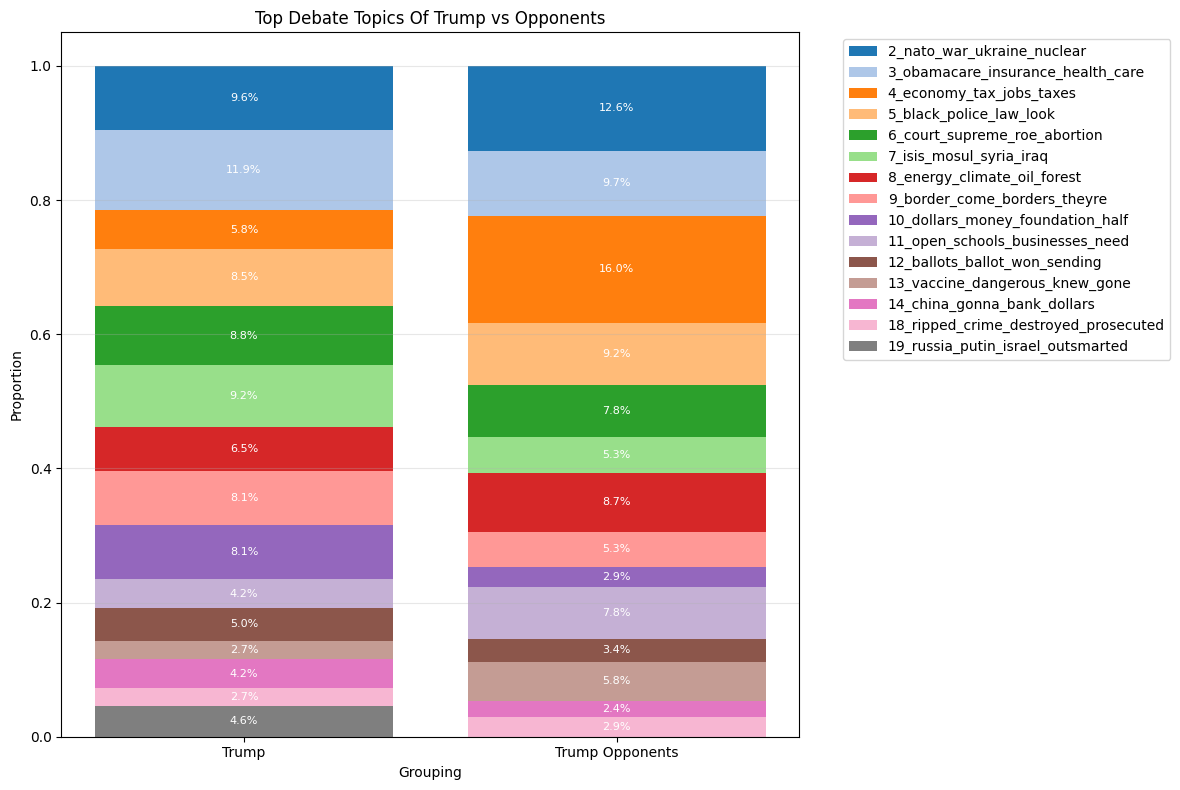

+--------------------------------------------------------------------------------------------------------------------------------------------------+
|                                                      Top BERTopic Terms in Category: Trump                                                       |
+----------+--------------------------------------+------------------------------------------------------------------------------------------------+
| Topic ID |                Label                 |                                           Top Terms                                            |
+----------+--------------------------------------+------------------------------------------------------------------------------------------------+
|    2     |      2_nato_war_ukraine_nuclear      |               nato, war, ukraine, nuclear, putin, hes, said, russia, world, dont               |
|    3     |  3_obamacare_insurance_health_care   | obamacare, insurance, health, care, affordable, preexi

In [95]:
plot_bertopic_by_category(topic_model_trump, df_trump_debates,selected_topics=[2, 3, 4, 5,6, 7, 8, 9, 10, 11, 12, 13, 14,18,19], 
proportions=True, title="Top Debate Topics Of Trump vs Opponents", topic_col='trump_topic')

In [96]:
df_only_trump=df_transcripts_candidates[(df_transcripts_candidates['grouping']=='Trump')]
df_trump_opponents=df_transcripts_candidates[(df_transcripts_candidates['grouping']=='Trump Opponents')]

docs_only_trump = df_only_trump['preprocessed_text_BERTopic'].tolist()
docs_trump_opponents=df_trump_opponents['preprocessed_text_BERTopic'].tolist()


topic_model_trump_only = BERTopic(embedding_model=embedding_model, vectorizer_model=vectorizer_model, verbose=True)
topics_trump_only, probs_trump_only = topic_model_trump_only.fit_transform(docs_only_trump)
df_only_trump['trump_topic'] = topics_trump_only

topic_model_trump_only.generate_topic_labels(nr_words=1)

2025-05-28 22:45:21,336 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/20 [00:00<?, ?it/s]

2025-05-28 22:46:16,073 - BERTopic - Embedding - Completed ✓
2025-05-28 22:46:16,075 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-05-28 22:46:28,036 - BERTopic - Dimensionality - Completed ✓
2025-05-28 22:46:28,038 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-28 22:46:28,064 - BERTopic - Cluster - Completed ✓
2025-05-28 22:46:28,068 - BERTopic - Representation - Fine-tuning topics using representation models.
/home/ucloud/.local/lib/python3.12/site-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning:

divide by zero encountered in divide

2025-05-28 22:46:28,115 - BERTopic - Representation - Completed ✓


['-1_know',
 '0_look',
 '1_shes',
 '2_companies',
 '3_russia',
 '4_effective',
 '5_obamacare',
 '6_isis',
 '7_justices',
 '8_dollars',
 '9_border',
 '10_ballots',
 '11_cages',
 '12_military']

In [97]:
topic_model_trump_opponent = BERTopic(embedding_model=embedding_model, vectorizer_model=vectorizer_model, verbose=True)
topics_trump_opponents, probs_trump_opponents = topic_model_trump_opponent.fit_transform(docs_trump_opponents)
df_trump_opponents['trump_topic'] = topics_trump_opponents

topic_model_trump_opponent.generate_topic_labels(nr_words=1)

2025-05-28 22:46:28,210 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/14 [00:00<?, ?it/s]

2025-05-28 22:47:07,860 - BERTopic - Embedding - Completed ✓
2025-05-28 22:47:07,869 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-05-28 22:47:14,469 - BERTopic - Dimensionality - Completed ✓
2025-05-28 22:47:14,471 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-28 22:47:14,489 - BERTopic - Cluster - Completed ✓
2025-05-28 22:47:14,492 - BERTopic - Representation - Fine-tuning topics using representation models.
/home/ucloud/.local/lib/python3.12/site-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning:

divide by zero encountered in divide

2025-05-28 22:47:14,528 - BERTopic - Representation - Completed ✓


['-1_thats',
 '0_tax',
 '1_said',
 '2_think',
 '3_insurance',
 '4_true',
 '5_shut',
 '6_court',
 '7_knew',
 '8_border',
 '9_know']

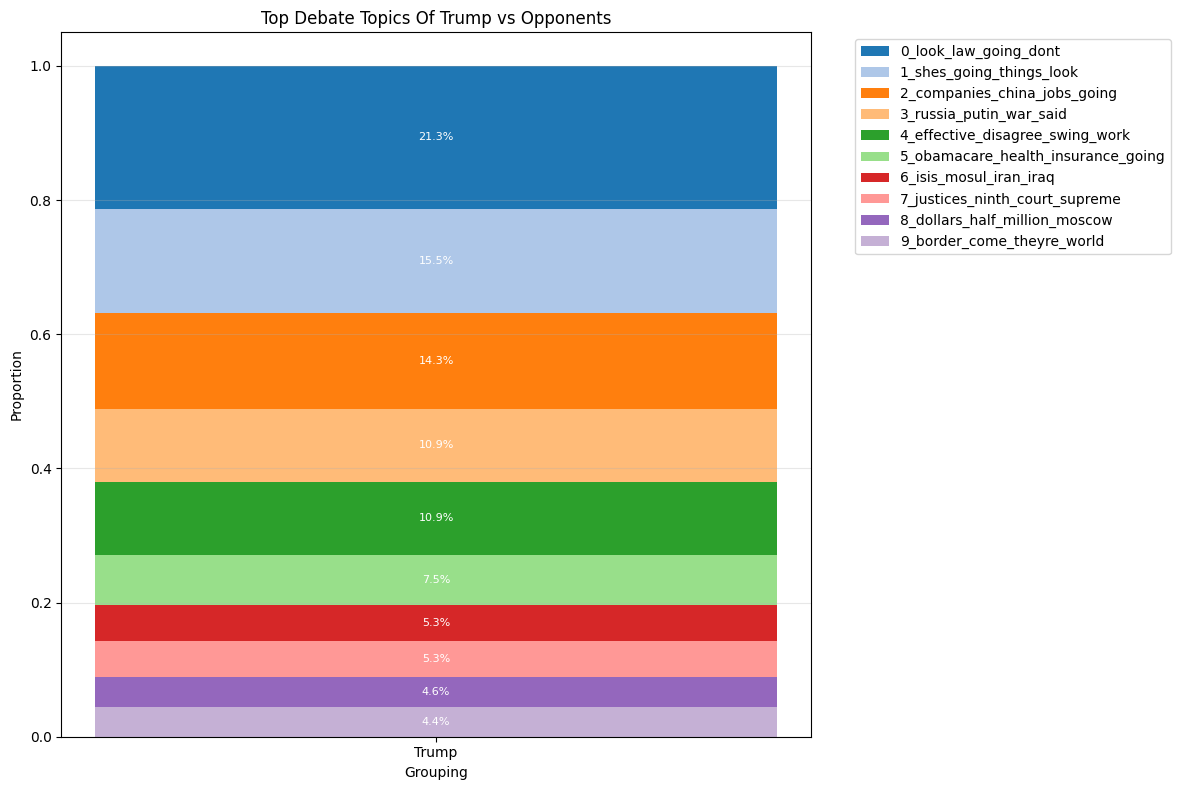

+-------------------------------------------------------------------------------------------------------------------------------------+
|                                                Top BERTopic Terms in Category: Trump                                                |
+----------+------------------------------------+-------------------------------------------------------------------------------------+
| Topic ID |               Label                |                                      Top Terms                                      |
+----------+------------------------------------+-------------------------------------------------------------------------------------+
|    0     |       0_look_law_going_dont        |              look, law, going, dont, black, did, just, order, said, say             |
|    1     |      1_shes_going_things_look      |            shes, going, things, look, dont, theyre, just, like, plan, lot           |
|    2     |    2_companies_china_jobs_going    

In [100]:
plot_bertopic_by_category(topic_model_trump_only, df_only_trump,top_n=10, 
proportions=True, title="Top Debate Topics Of Trump vs Opponents", topic_col='trump_topic')

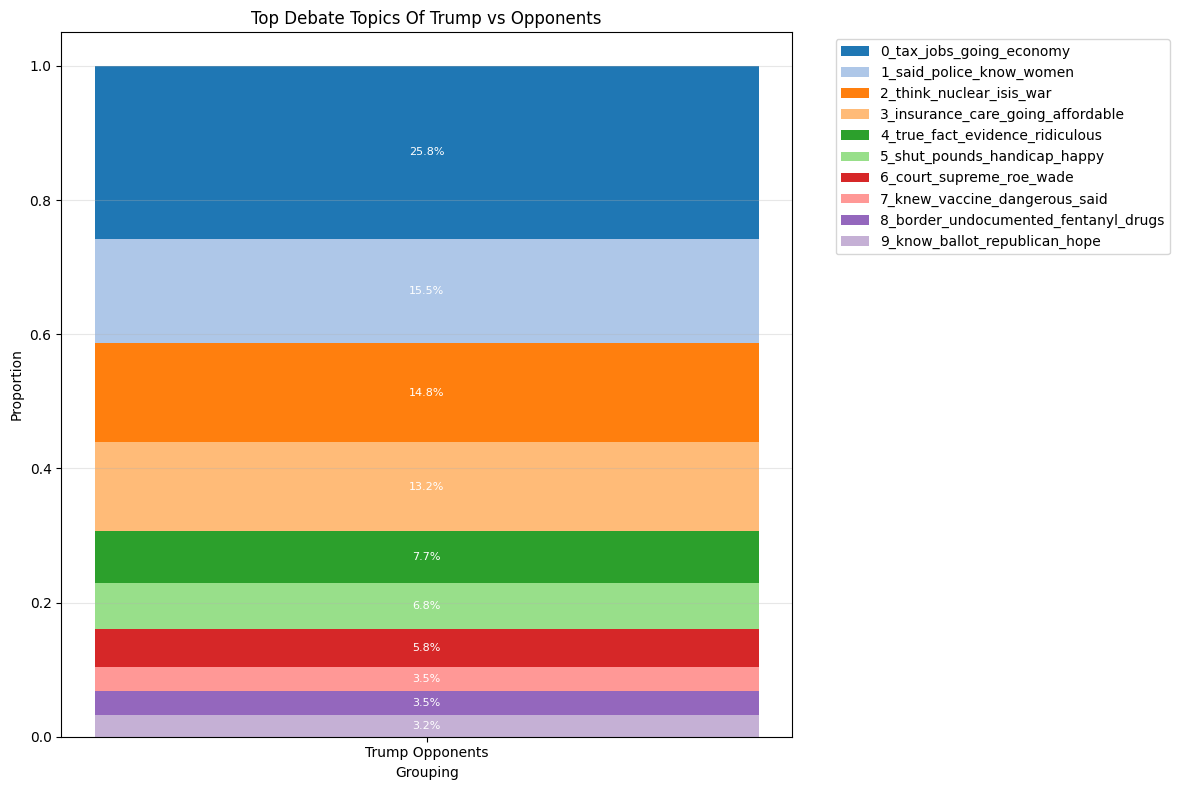

+--------------------------------------------------------------------------------------------------------------------------------------------------+
|                                                 Top BERTopic Terms in Category: Trump Opponents                                                  |
+----------+--------------------------------------+------------------------------------------------------------------------------------------------+
| Topic ID |                Label                 |                                           Top Terms                                            |
+----------+--------------------------------------+------------------------------------------------------------------------------------------------+
|    0     |       0_tax_jobs_going_economy       |                tax, jobs, going, economy, plan, new, taxes, million, make, sure                |
|    1     |       1_said_police_know_women       |                 said, police, know, women, law, black,

In [102]:
plot_bertopic_by_category(topic_model_trump_opponent, df_trump_opponents,top_n=10,
proportions=True, title="Top Debate Topics Of Trump vs Opponents", topic_col='trump_topic')